In [7]:
import pandas as pd

# Load the datasets
train_df = pd.read_csv('train.csv', low_memory=False)
store_df = pd.read_csv('store.csv', low_memory=False)

# Merge the datasets on the 'Store' column
merged_df = pd.merge(train_df, store_df, on='Store', how='inner')

# Filter the data for StoreType 'a'
filtered_df = merged_df[merged_df['StoreType'] == 'a']

# Check if the filtered data contains all three types of assortments
# Assuming assortment types are 'a', 'b', 'c'
# If the assortment types are different (e.g., 'A', 'B', 'C' or 1, 2, 3), this part might need adjustment.
required_assortments = {'a', 'b', 'c'}
found_assortments = set(filtered_df['Assortment'].unique())

if required_assortments.issubset(found_assortments):
    print("The filtered data for StoreType 'a' contains all three required assortment types.")
else:
    missing_assortments = required_assortments - found_assortments
    print(f"The filtered data for StoreType 'a' is missing the following assortment types: {missing_assortments}.")

# Display the first few rows of the filtered data and its shape for review
print("\nFiltered Data (StoreType 'a') Head:")
print(filtered_df.head())
print(f"\nShape of Filtered Data: {filtered_df.shape}")

The filtered data for StoreType 'a' is missing the following assortment types: {'b'}.

Filtered Data (StoreType 'a') Head:
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   
5      6          5  2015-07-31   5651        589     1      1            0   
6      7          5  2015-07-31  15344       1414     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
1              1         a          a                570.0   
2              1         a          a              14130.0   
4              1         a          a              29910.0   
5              1         a          a                310.0   
6              1         a          c              24000.0   

   CompetitionOpenSinceMonth 

In [8]:
print(merged_df['StoreType'].value_counts())

StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64


In [9]:
# Filter store_df for Assortment 'b' and count unique StoreTypes
assortment_b_store_types = store_df[store_df['Assortment'] == 'b']['StoreType'].unique()
print(f"Assortment 'b' is present in {assortment_b_store_types} store types.")

Assortment 'b' is present in ['b'] store types.


In [10]:
store_type_B_Assortment_types=store_df[store_df['StoreType']=='b']['Assortment'].unique()
store_type_B_Assortment_types

array(['a', 'b', 'c'], dtype=object)

## Exploratory Data Analysis (EDA) on Filtered Data

In [11]:
# Check for missing values in the 'Sales' column
missing_sales = filtered_df['Sales'].isnull().sum()
print(f"Missing values in 'Sales' column: {missing_sales}")

Missing values in 'Sales' column: 0


In [12]:
# Calculate summary statistics for filtered_df
print("\nSummary Statistics for Filtered Data:")
display(filtered_df.describe())


Summary Statistics for Filtered Data:


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,551627.000000,551627.000000,551627.000000,551627.00000,551627.000000,551627.000000,551627.000000,550685.000000,390067.000000,390067.000000,551627.000000,257886.000000,257886.000000
mean,560.079706,3.998278,5738.179710,659.03488,0.828598,0.381606,0.178405,5166.453217,7.176508,2008.598584,0.467501,23.658601,2011.861536
std,325.816164,1.997385,3964.028134,462.93032,0.376860,0.485781,0.382854,8484.732026,3.243129,6.630736,0.498943,13.675661,1.718458
min,2.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,276.000000,2.000000,3508.000000,414.00000,1.000000,0.000000,0.000000,460.000000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.000000,4.000000,5618.000000,647.00000,1.000000,0.000000,0.000000,1790.000000,8.000000,2010.000000,0.000000,22.000000,2012.000000
75%,848.000000,6.000000,7860.000000,890.00000,1.000000,1.000000,0.000000,5080.000000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1114.000000,7.000000,41551.000000,7388.00000,1.000000,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,48.000000,2015.000000


### Univariate Analysis

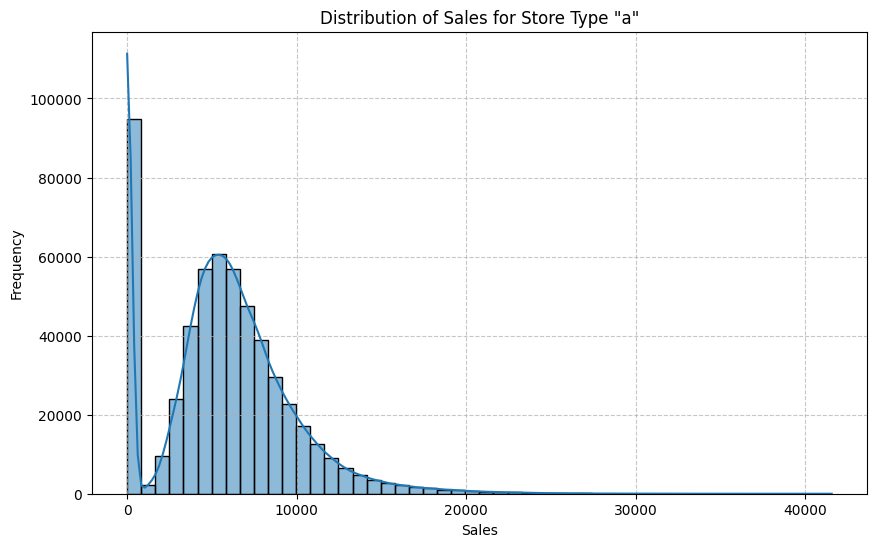

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize overall sales distribution
plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['Sales'], kde=True, bins=50)
plt.title('Distribution of Sales for Store Type "a"')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

--- Starting Univariate Analysis of filtered_df columns ---

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 551627 entries, 1 to 1017207
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      551627 non-null  int64         
 1   DayOfWeek                  551627 non-null  int64         
 2   Date                       551627 non-null  datetime64[ns]
 3   Sales                      551627 non-null  int64         
 4   Customers                  551627 non-null  int64         
 5   Open                       551627 non-null  int64         
 6   Promo                      551627 non-null  int64         
 7   StateHoliday               551627 non-null  object        
 8   SchoolHoliday              551627 non-null  int64         
 9   StoreType                  551627 non-null  object        
 10  Assortment                 551627 non-null 

/tmp/ipykernel_392/94533042.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Date'] = pd.to_datetime(filtered_df['Date'])


,count
Store,
2,942
3,942
5,942
6,942
7,942
...,...
1107,758
1108,942
1111,942


/tmp/ipykernel_392/94533042.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)


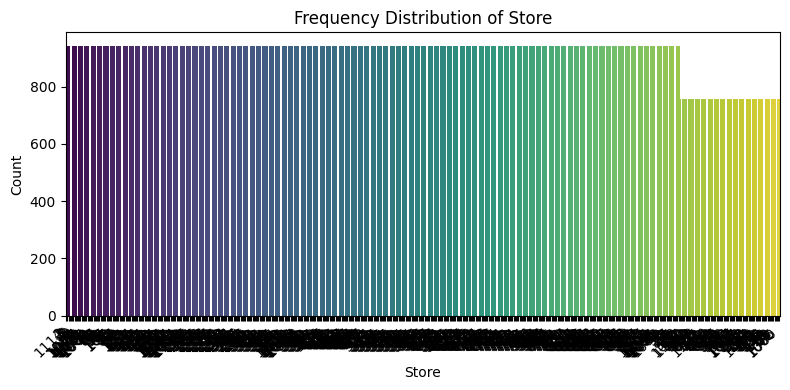


--- Analyzing column: DayOfWeek ---
Value Counts:


,count
DayOfWeek,
1,78484
2,79001
3,79002
4,79086
5,79086
6,78484
7,78484


/tmp/ipykernel_392/94533042.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)


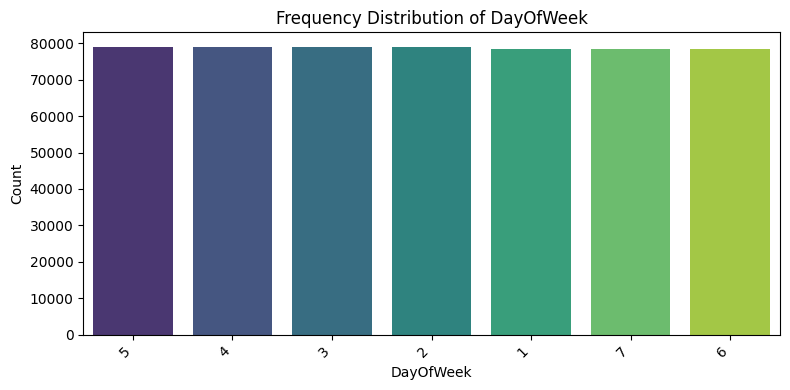


--- Analyzing column: Date ---
Min Date: 2013-01-01 00:00:00, Max Date: 2015-07-31 00:00:00

--- Analyzing column: Sales ---
Descriptive Statistics:


,Sales
count,551627.000000
mean,5738.179710
std,3964.028134
min,0.000000
25%,3508.000000
50%,5618.000000
75%,7860.000000
max,41551.000000


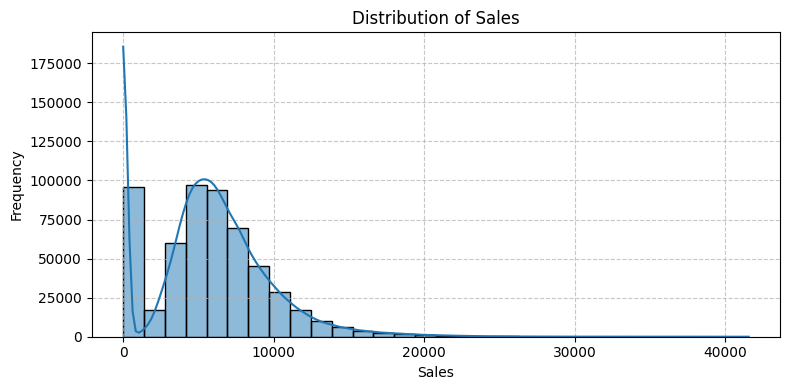


--- Analyzing column: Customers ---
Descriptive Statistics:


,Customers
count,551627.00000
mean,659.03488
std,462.93032
min,0.00000
25%,414.00000
50%,647.00000
75%,890.00000
max,7388.00000


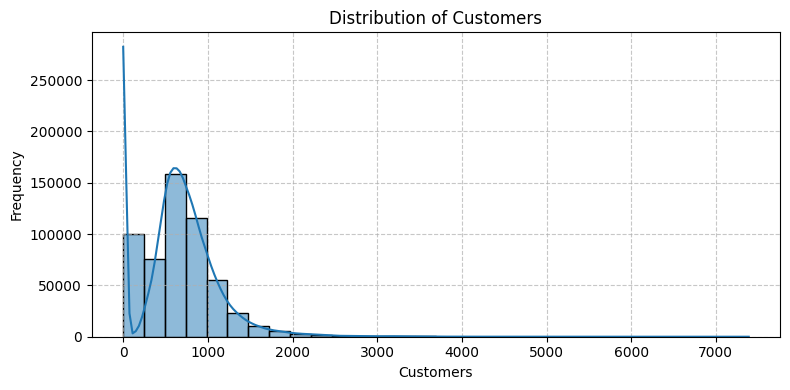


--- Analyzing column: Open ---
Value Counts:


,count
Open,
0,94550
1,457077


/tmp/ipykernel_392/94533042.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)


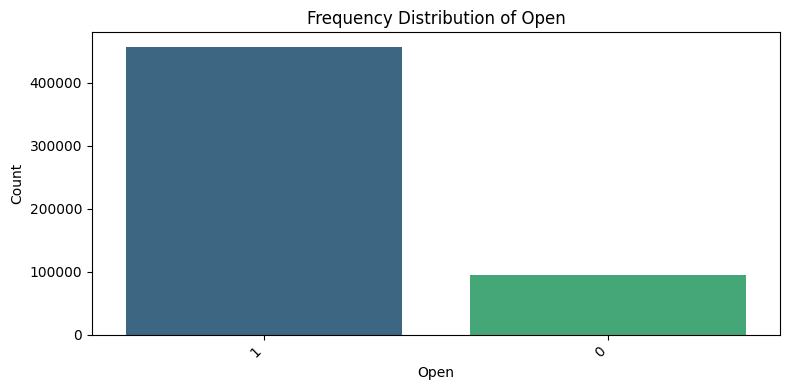


--- Analyzing column: Promo ---
Value Counts:


,count
Promo,
0,341123
1,210504


/tmp/ipykernel_392/94533042.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)


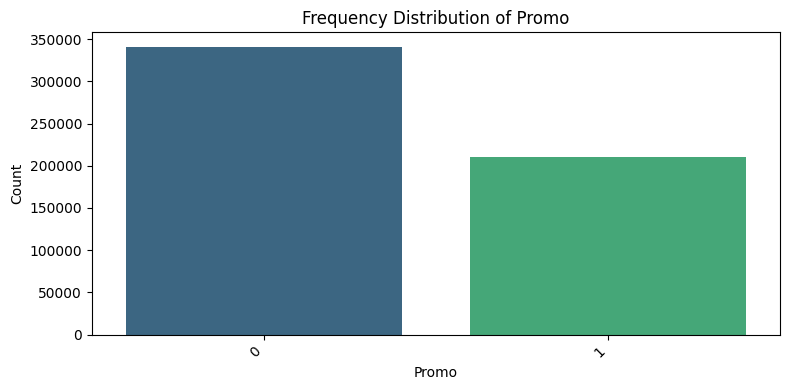


--- Analyzing column: StateHoliday ---
Value Counts:


,count
StateHoliday,
0,534942
a,10833
b,3612
c,2240


/tmp/ipykernel_392/94533042.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)


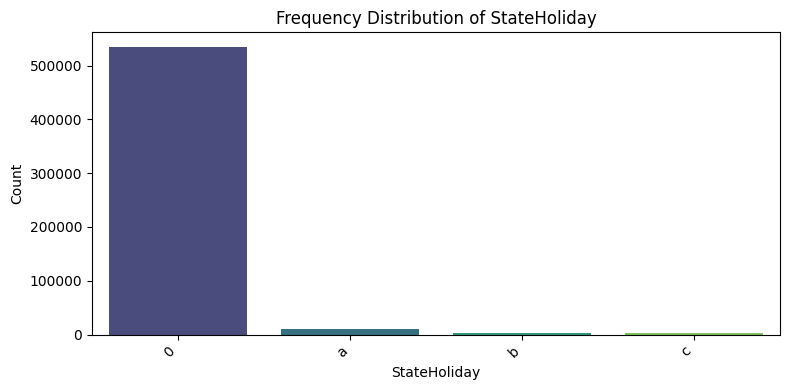


--- Analyzing column: SchoolHoliday ---
Value Counts:


,count
SchoolHoliday,
0,453214
1,98413


/tmp/ipykernel_392/94533042.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)


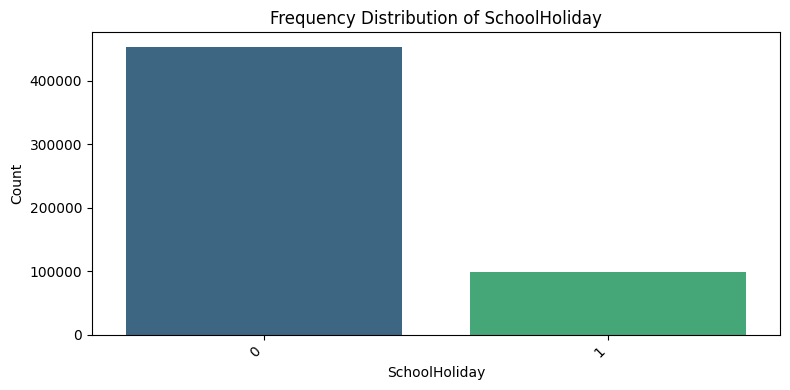


--- Analyzing column: StoreType ---
Value Counts:


,count
StoreType,
a,551627


/tmp/ipykernel_392/94533042.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)


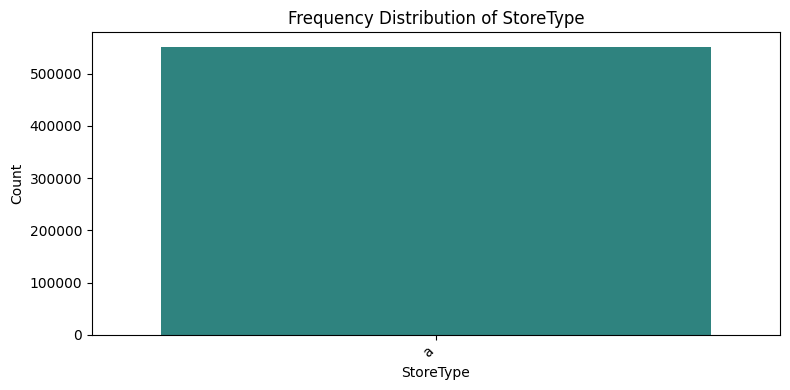


--- Analyzing column: Assortment ---
Value Counts:


,count
Assortment,
a,346389
c,205238


/tmp/ipykernel_392/94533042.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)


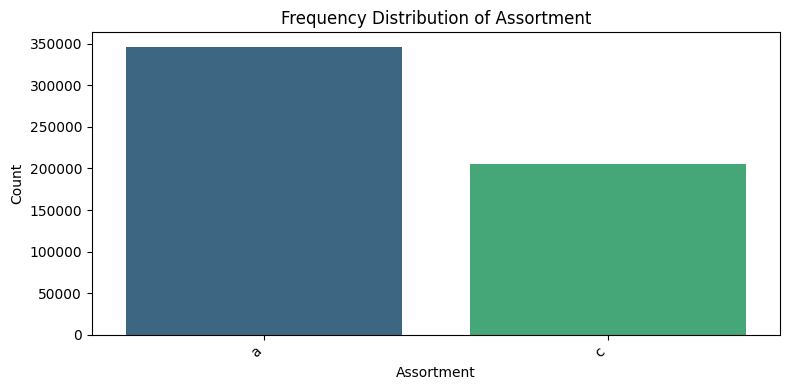


--- Analyzing column: CompetitionDistance ---
Missing values: 942 (0.17%)
Descriptive Statistics:


,CompetitionDistance
count,550685.000000
mean,5166.453217
std,8484.732026
min,20.000000
25%,460.000000
50%,1790.000000
75%,5080.000000
max,75860.000000


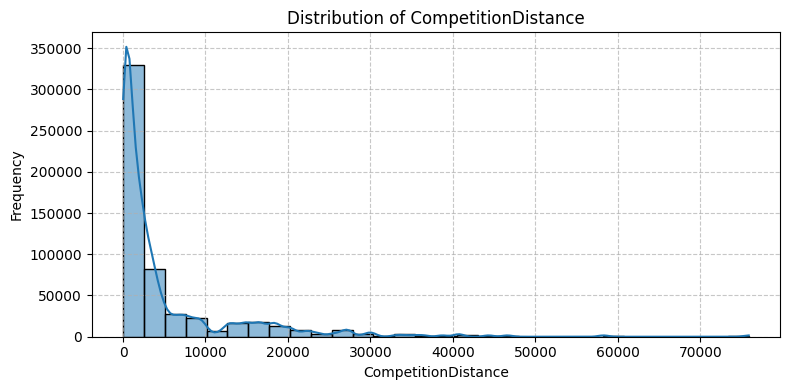


--- Analyzing column: CompetitionOpenSinceMonth ---
Missing values: 161560 (29.29%)
Descriptive Statistics:


,CompetitionOpenSinceMonth
count,390067.000000
mean,7.176508
std,3.243129
min,1.000000
25%,4.000000
50%,8.000000
75%,10.000000
max,12.000000


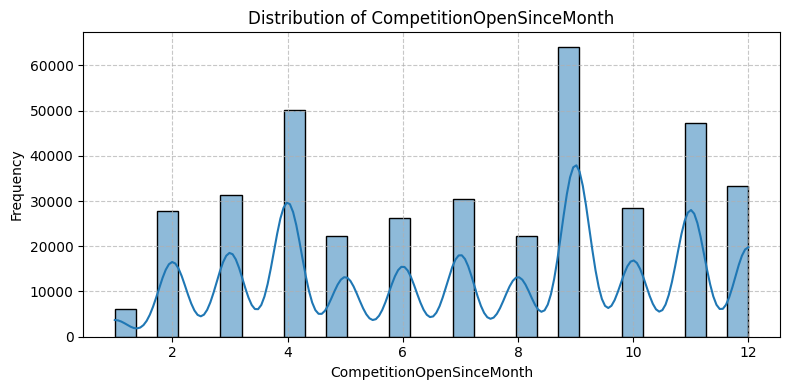


--- Analyzing column: CompetitionOpenSinceYear ---
Missing values: 161560 (29.29%)
Descriptive Statistics:


,CompetitionOpenSinceYear
count,390067.000000
mean,2008.598584
std,6.630736
min,1900.000000
25%,2006.000000
50%,2010.000000
75%,2013.000000
max,2015.000000


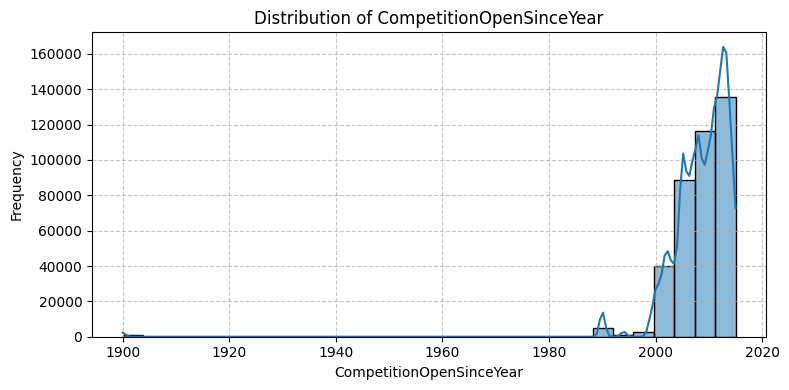


--- Analyzing column: Promo2 ---
Value Counts:


,count
Promo2,
0,293741
1,257886


/tmp/ipykernel_392/94533042.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)


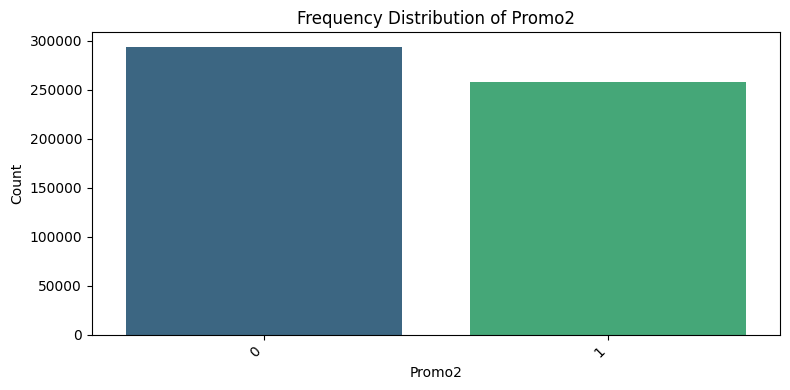


--- Analyzing column: Promo2SinceWeek ---
Missing values: 293741 (53.25%)
Descriptive Statistics:


,Promo2SinceWeek
count,257886.000000
mean,23.658601
std,13.675661
min,1.000000
25%,13.000000
50%,22.000000
75%,37.000000
max,48.000000


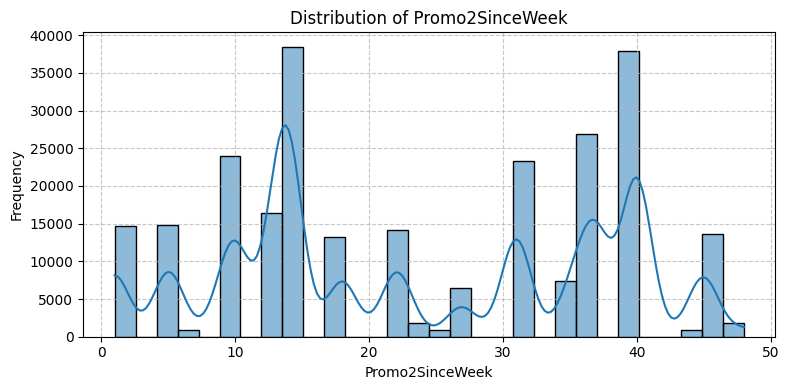


--- Analyzing column: Promo2SinceYear ---
Missing values: 293741 (53.25%)
Descriptive Statistics:


,Promo2SinceYear
count,257886.000000
mean,2011.861536
std,1.718458
min,2009.000000
25%,2011.000000
50%,2012.000000
75%,2013.000000
max,2015.000000


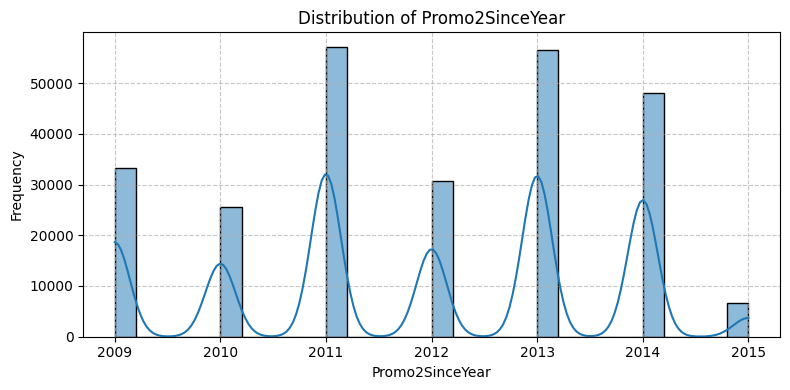


--- Analyzing column: PromoInterval ---
Missing values: 293741 (53.25%)
Value Counts:


,count
PromoInterval,
"Feb,May,Aug,Nov",60332
"Jan,Apr,Jul,Oct",154590
"Mar,Jun,Sept,Dec",42964
NaN,293741


/tmp/ipykernel_392/94533042.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)


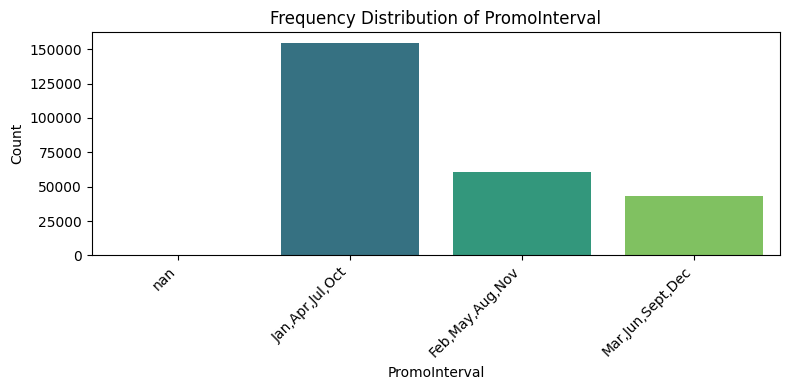


--- Univariate Analysis Complete ---


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Date' column is datetime type for analysis
filtered_df['Date'] = pd.to_datetime(filtered_df['Date'])

print("--- Starting Univariate Analysis of filtered_df columns ---")
# Display DataFrame information for a quick overview of dtypes and non-null counts
print("\nDataFrame Info:")
filtered_df.info()

# Define columns to treat as categorical-like (even if numeric)
categorical_like_cols = ['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Assortment', 'Promo2', 'PromoInterval', 'StoreType']
# Define columns to treat as numerical
numerical_cols = ['Sales', 'Customers', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear']

for col in filtered_df.columns:
    print(f"\n--- Analyzing column: {col} ---")

    # Print missing value count for the column
    missing_count = filtered_df[col].isnull().sum()
    if missing_count > 0:
        print(f"Missing values: {missing_count} ({missing_count / len(filtered_df):.2%})")

    if col == 'Date':
        # For Date column: show min and max dates
        print(f"Min Date: {filtered_df[col].min()}, Max Date: {filtered_df[col].max()}")
    elif col in categorical_like_cols:
        # Categorical columns: print value counts and plot countplot
        print("Value Counts:")
        display(filtered_df[col].value_counts(dropna=False).sort_index())
        plt.figure(figsize=(8, 4))
        sns.countplot(x=col, data=filtered_df, palette='viridis', order=filtered_df[col].value_counts(dropna=False).index)
        plt.title(f'Frequency Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    elif col in numerical_cols:
        # Numerical columns: print descriptive statistics and plot histogram
        print("Descriptive Statistics:")
        display(filtered_df[col].describe())
        plt.figure(figsize=(8, 4))
        sns.histplot(filtered_df[col].dropna(), kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

print("\n--- Univariate Analysis Complete ---")

### BiVariate Analysis

--- Starting Bivariate Analysis with Sales ---

--- Analyzing Sales vs Store ---


/tmp/ipykernel_392/4184474614.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Date'] = pd.to_datetime(filtered_df['Date'], errors='coerce')


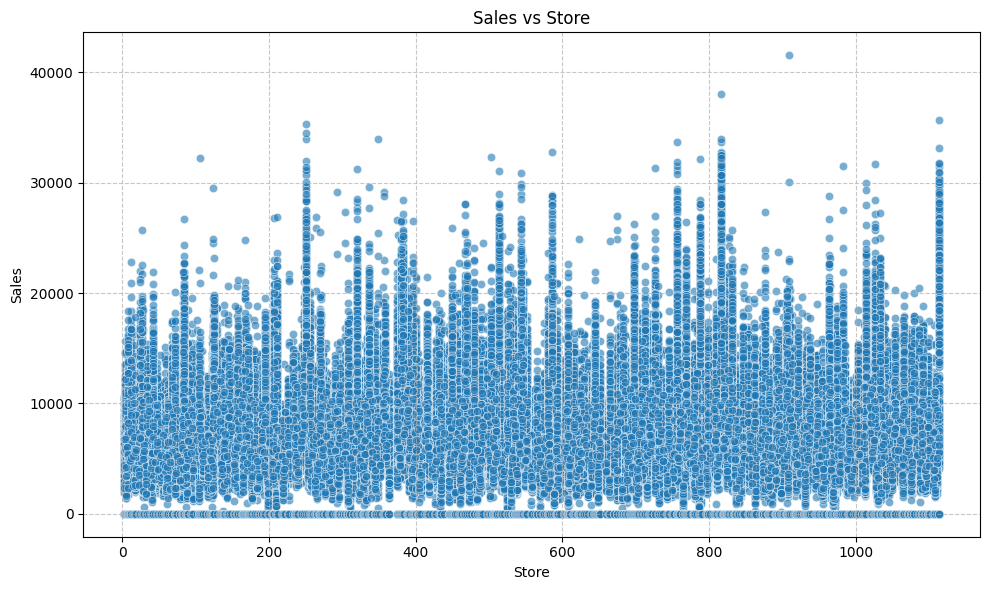

Correlation between Sales and Store: 0.0181

--- Analyzing Sales vs DayOfWeek ---


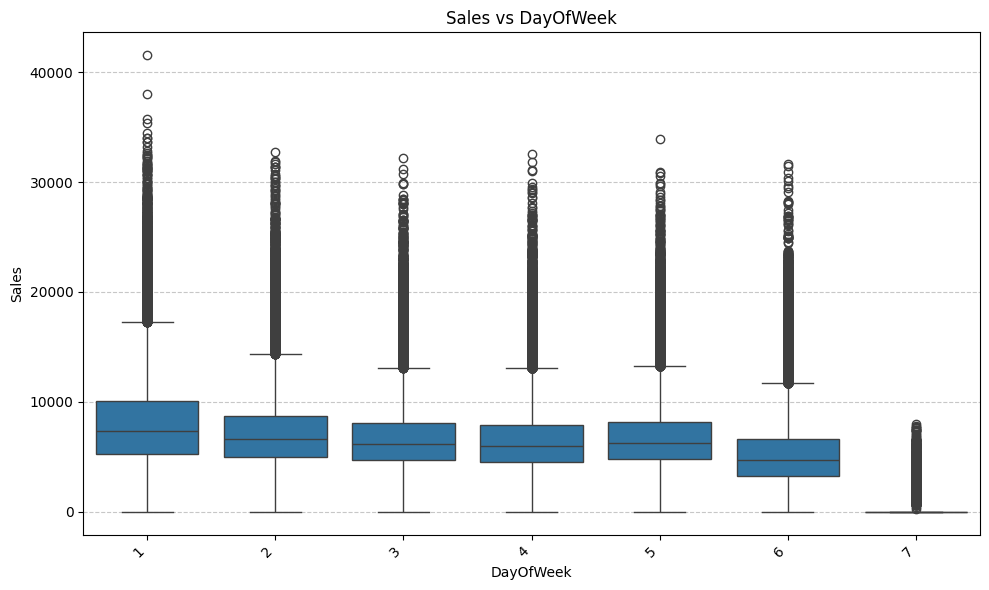

Mean Sales by DayOfWeek:


,Sales
DayOfWeek,
1,7924.611934
2,7212.646675
3,6664.173464
5,6648.808335
4,6313.106618
6,5335.876841
7,40.814943



--- Analyzing Sales vs Customers ---


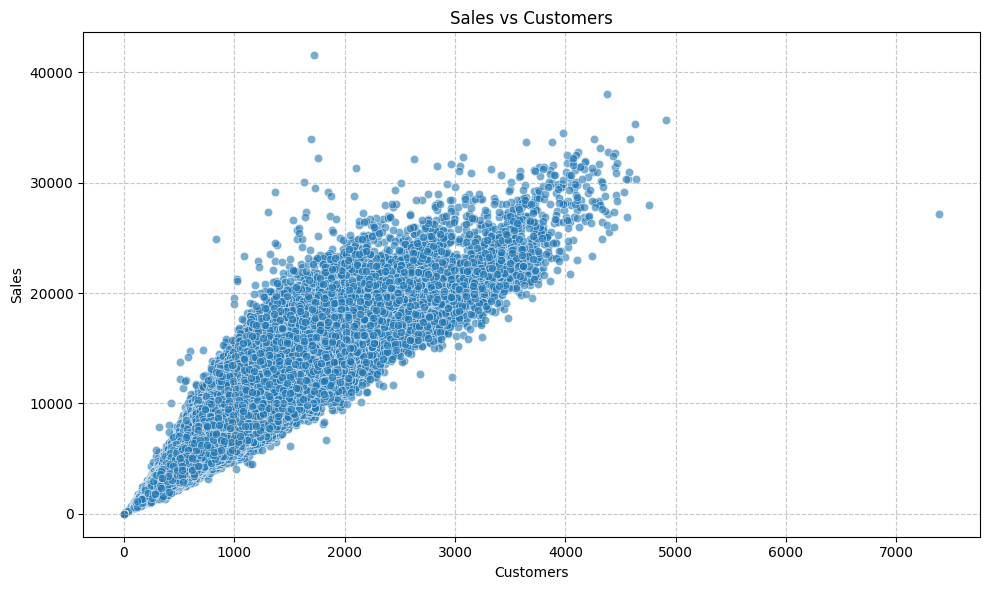

Correlation between Sales and Customers: 0.9442

--- Analyzing Sales vs Open ---


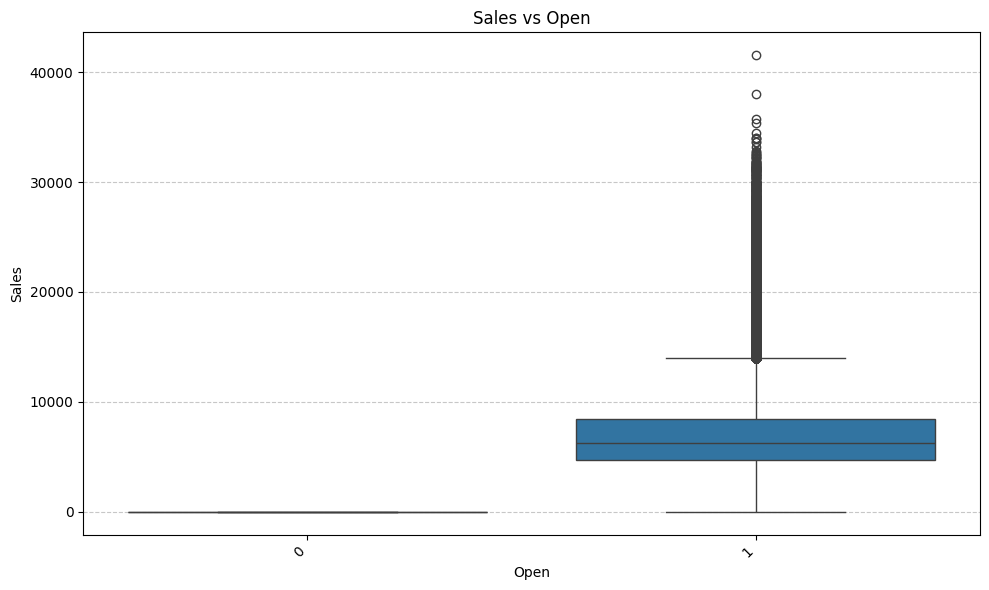

Mean Sales by Open:


,Sales
Open,
1,6925.167661
0,0.000000



--- Analyzing Sales vs Promo ---


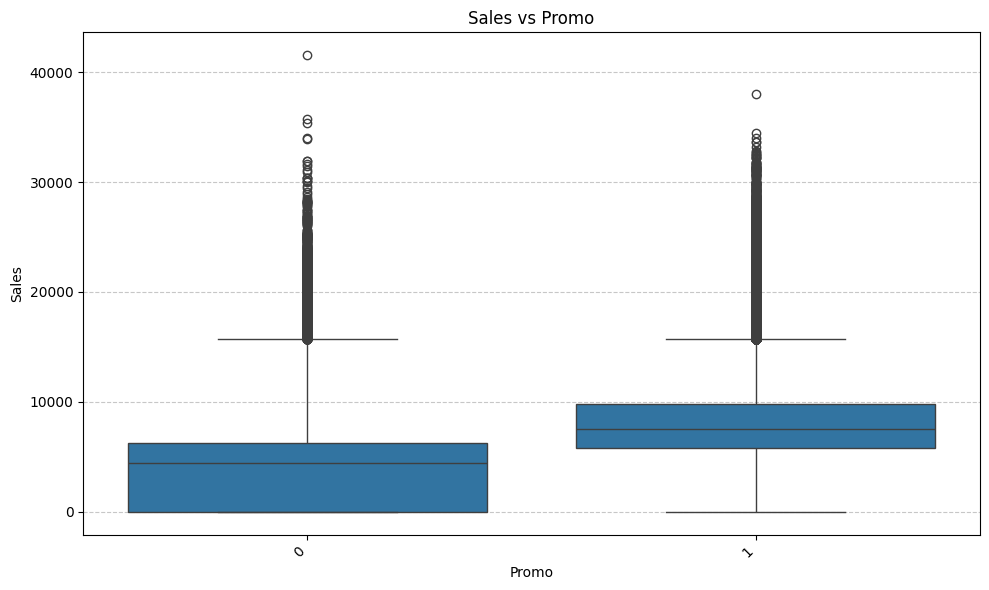

Mean Sales by Promo:


,Sales
Promo,
1,8068.080939
0,4300.418175



--- Analyzing Sales vs StateHoliday ---


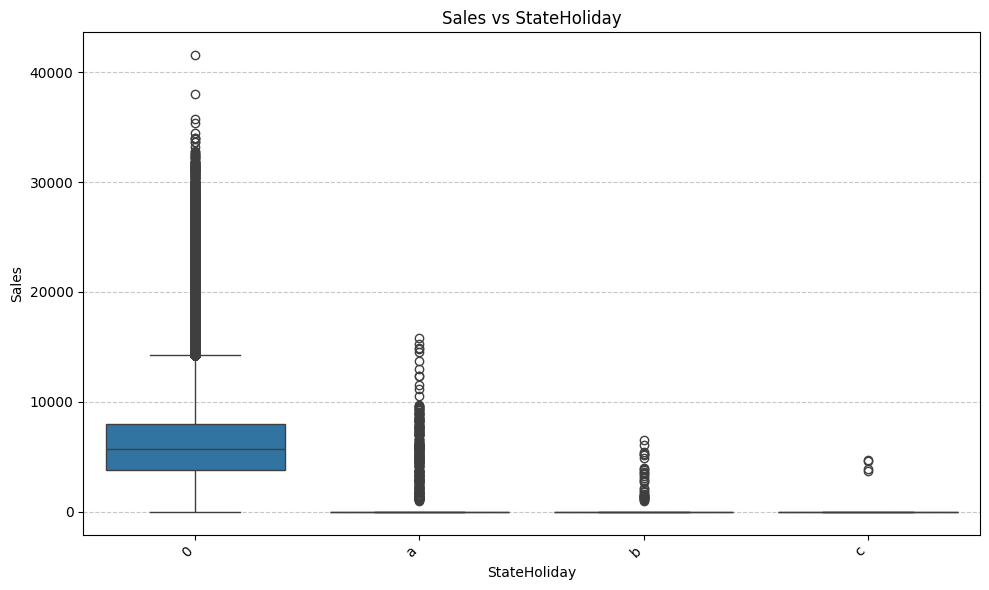

Mean Sales by StateHoliday:


,Sales
StateHoliday,
0,5914.561455
a,117.095449
b,28.258306
c,7.571875



--- Analyzing Sales vs SchoolHoliday ---


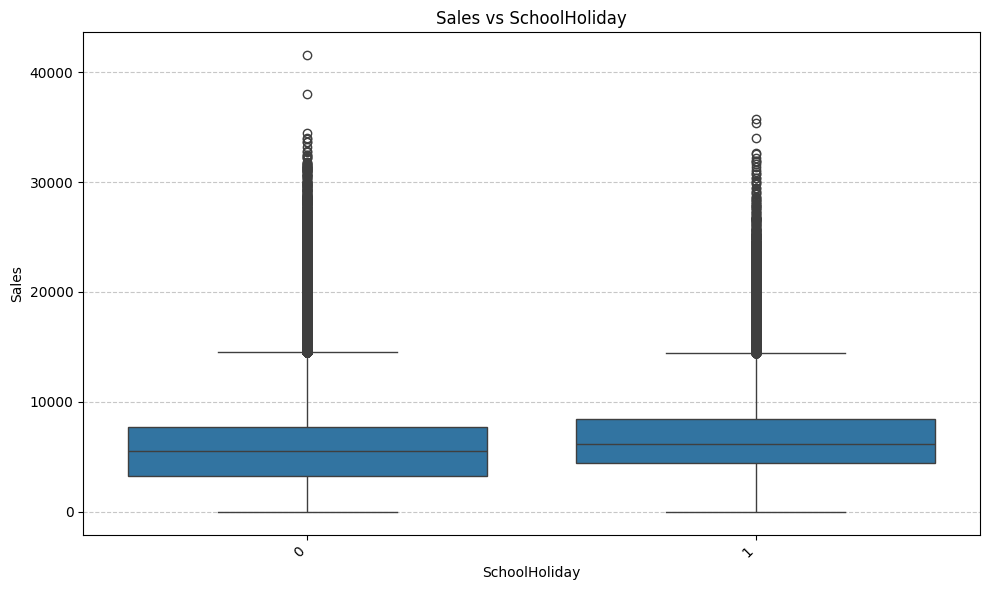

Mean Sales by SchoolHoliday:


,Sales
SchoolHoliday,
1,6527.078496
0,5566.874552



--- Analyzing Sales vs StoreType ---


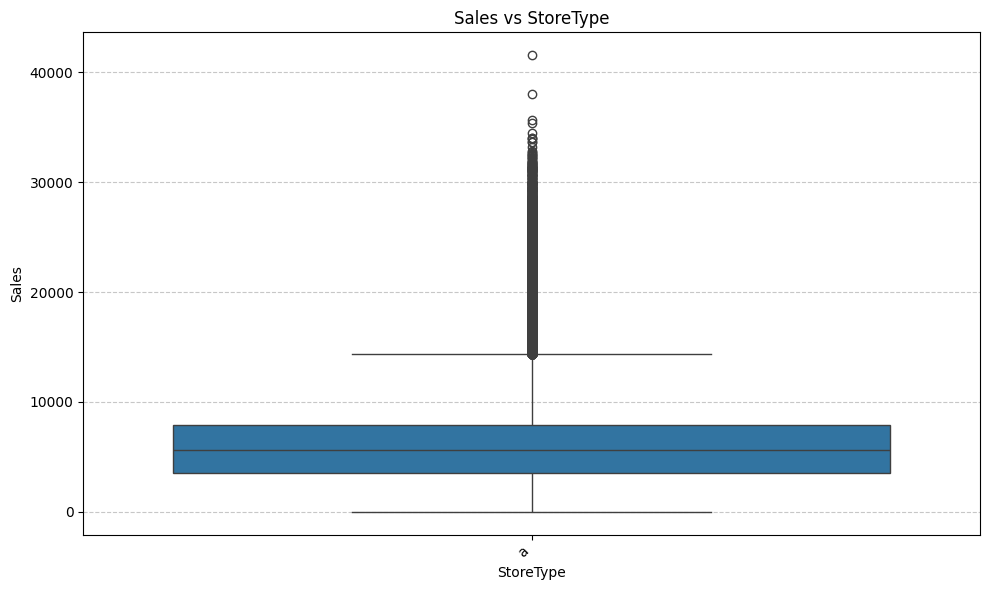

Mean Sales by StoreType:


,Sales
StoreType,
a,5738.17971



--- Analyzing Sales vs Assortment ---


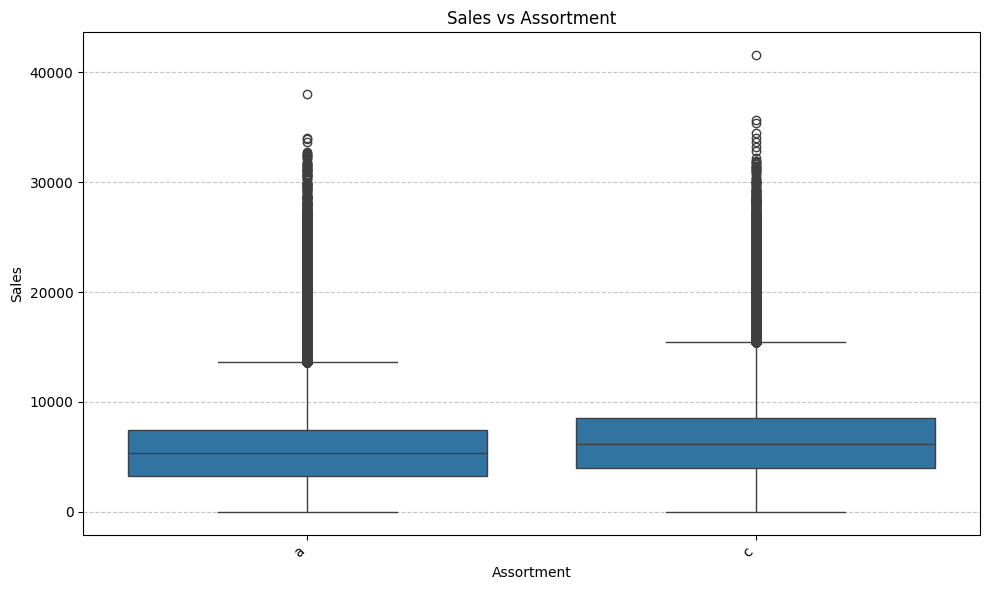

Mean Sales by Assortment:


,Sales
Assortment,
c,6310.867032
a,5398.858310



--- Analyzing Sales vs CompetitionDistance ---


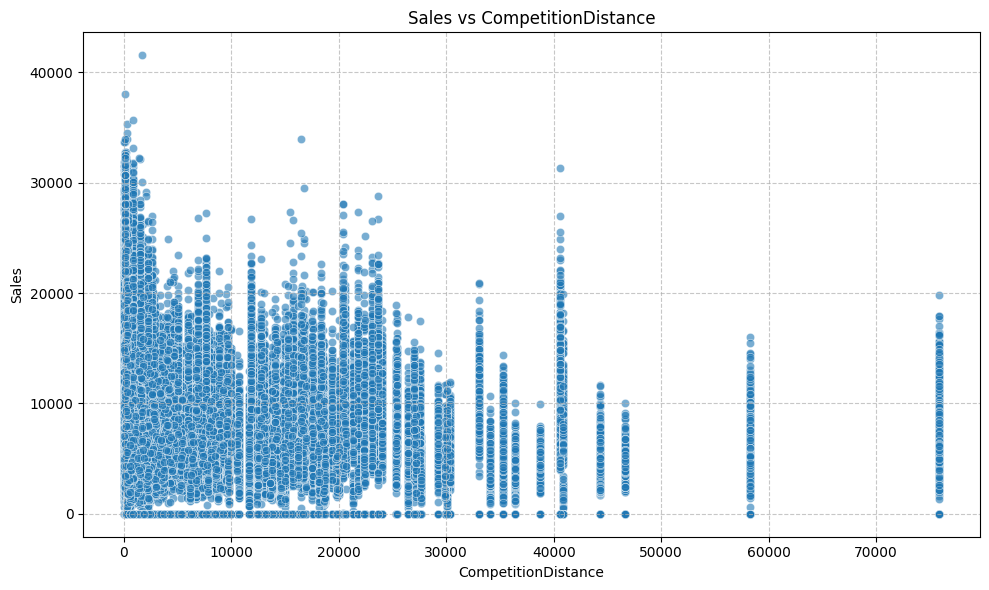

Correlation between Sales and CompetitionDistance: -0.0209

--- Analyzing Sales vs Promo2 ---


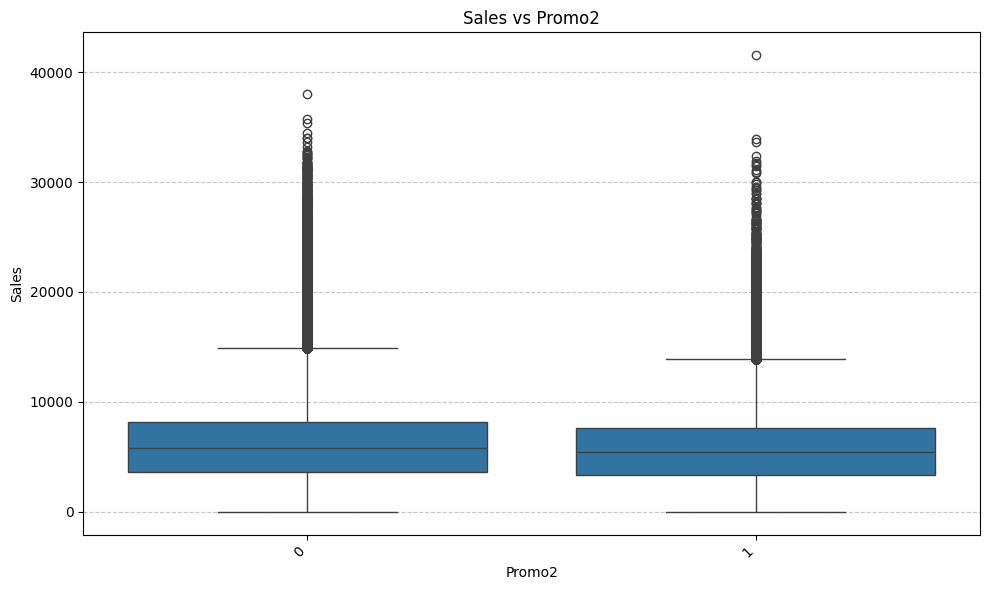

Mean Sales by Promo2:


,Sales
Promo2,
0,5977.170735
1,5465.960735



--- Analyzing Sales vs PromoInterval ---


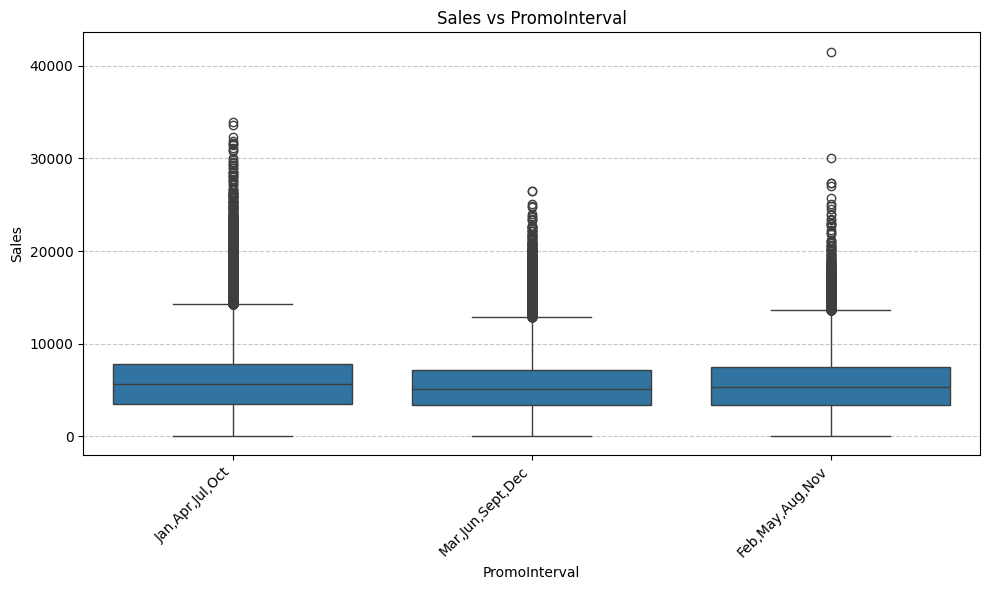

Mean Sales by PromoInterval:


,Sales
PromoInterval,
"Jan,Apr,Jul,Oct",5610.174507
"Feb,May,Aug,Nov",5290.689767
"Mar,Jun,Sept,Dec",5193.184480



--- Bivariate Analysis Complete ---


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Target variable
target_variable = 'Sales'

# Columns to exclude from bivariate analysis
exclude_cols = [
    target_variable,
    'Date',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'Promo2SinceWeek',
    'Promo2SinceYear'
]

# Ensure 'Date' column is datetime type if not already for potential future use (though excluded here)
if 'Date' in filtered_df.columns:
    filtered_df['Date'] = pd.to_datetime(filtered_df['Date'], errors='coerce')

print(f"--- Starting Bivariate Analysis with {target_variable} ---")

for col in filtered_df.columns:
    if col in exclude_cols:
        continue # Skip excluded columns and the target variable itself

    print(f"\n--- Analyzing {target_variable} vs {col} ---")

    # Handle categorical columns (object dtype or low unique count)
    if filtered_df[col].dtype == 'object' or filtered_df[col].nunique() < 20:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=col, y=target_variable, data=filtered_df)
        plt.title(f'{target_variable} vs {col}')
        plt.xlabel(col)
        plt.ylabel(target_variable)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # Optional: Print mean sales for each category
        print(f"Mean {target_variable} by {col}:")
        display(filtered_df.groupby(col)[target_variable].mean().sort_values(ascending=False))

    # Handle numerical columns
    else:
        # Scatter plot for numerical features
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=col, y=target_variable, data=filtered_df, alpha=0.6)
        plt.title(f'{target_variable} vs {col}')
        plt.xlabel(col)
        plt.ylabel(target_variable)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # Calculate and print correlation
        correlation = filtered_df[target_variable].corr(filtered_df[col])
        print(f"Correlation between {target_variable} and {col}: {correlation:.4f}")

print("\n--- Bivariate Analysis Complete ---")

## Correlation Matrix for Numerical Columns


Correlation Matrix for Numerical Columns:


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
Store,1.000000,-0.000010,0.018131,0.020440,0.000065,0.000073,-0.000152,-0.006216,-0.040573,-0.024510,0.022167,0.056165,0.053985
DayOfWeek,-0.000010,1.000000,-0.493064,-0.454663,-0.533631,-0.392927,-0.213219,-0.000038,0.000013,-0.000053,0.000182,0.000227,0.000091
Sales,0.018131,-0.493064,1.000000,0.944171,0.658376,0.461717,0.092738,-0.020885,-0.047888,0.008115,-0.064345,0.055541,-0.029556
Customers,0.020440,-0.454663,0.944171,1.000000,0.647484,0.359008,0.084302,-0.077177,-0.041310,0.026167,-0.105711,0.014034,0.000416
Open,0.000065,-0.533631,0.658376,0.647484,1.000000,0.298036,0.091283,0.015863,0.001894,0.004300,-0.006419,-0.004434,0.000109
Promo,0.000073,-0.392927,0.461717,0.359008,0.298036,1.000000,0.069469,0.000216,-0.000053,0.000316,-0.001068,-0.001317,-0.000527
SchoolHoliday,-0.000152,-0.213219,0.092738,0.084302,0.091283,0.069469,1.000000,-0.003859,-0.000818,0.001887,-0.006844,-0.002210,-0.007380
CompetitionDistance,-0.006216,-0.000038,-0.020885,-0.077177,0.015863,0.000216,-0.003859,1.000000,-0.110952,0.032444,-0.155602,0.045715,-0.212182
CompetitionOpenSinceMonth,-0.040573,0.000013,-0.047888,-0.041310,0.001894,-0.000053,-0.000818,-0.110952,1.000000,0.013883,0.028884,-0.014314,0.042720
CompetitionOpenSinceYear,-0.024510,-0.000053,0.008115,0.026167,0.004300,0.000316,0.001887,0.032444,0.013883,1.000000,-0.048573,-0.095974,-0.020344


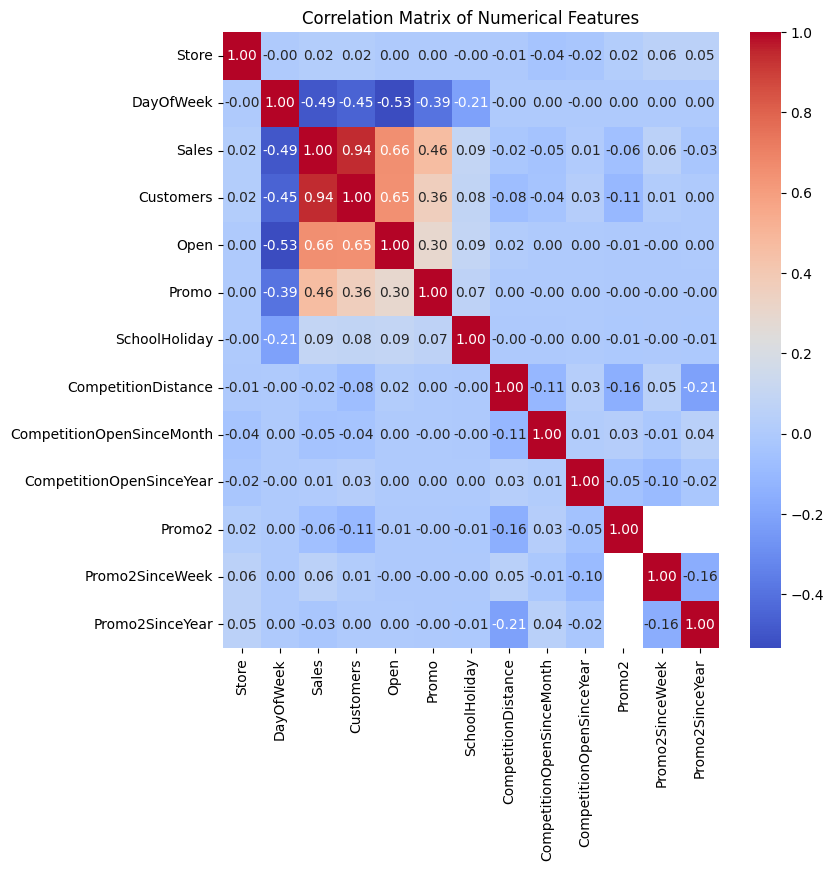

In [16]:
# Select only numerical columns for correlation matrix
numerical_df = filtered_df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix
print("\nCorrelation Matrix for Numerical Columns:")
display(correlation_matrix)

# Optionally, visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Converting categorical variables to numerical using Label Encoding...
  - Encoded 'DayOfWeek'
  - Encoded 'Open'
  - Encoded 'Promo'
  - Encoded 'StateHoliday'
  - Encoded 'SchoolHoliday'
  - Encoded 'StoreType'
  - Encoded 'Assortment'
  - Encoded 'Promo2'
  - Encoded 'PromoInterval'
  - Encoded 'Store'

Correlation Matrix for all Numerical and Encoded Categorical Columns:


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Store,1.000000,-0.000012,-0.019023,-0.022545,-0.002651,0.000091,0.000838,-0.001903,NaN,-0.043111,0.041004,0.007272,-0.064587,-0.070431,-0.006206,-0.022132,0.041554
DayOfWeek,-0.000012,1.000000,-0.493064,-0.454663,-0.533631,-0.392927,-0.043646,-0.213219,NaN,-0.000076,-0.000038,0.000013,-0.000053,0.000182,0.000227,0.000091,-0.000174
Sales,-0.019023,-0.493064,1.000000,0.944171,0.658376,0.461717,-0.226906,0.092738,NaN,0.111206,-0.020885,-0.047888,0.008115,-0.064345,0.055541,-0.029556,0.058917
Customers,-0.022545,-0.454663,0.944171,1.000000,0.647484,0.359008,-0.222953,0.084302,NaN,0.089914,-0.077177,-0.041310,0.026167,-0.105711,0.014034,0.000416,0.094471
Open,-0.002651,-0.533631,0.658376,0.647484,1.000000,0.298036,-0.342948,0.091283,NaN,0.009596,0.015863,0.001894,0.004300,-0.006419,-0.004434,0.000109,0.006683
Promo,0.000091,-0.392927,0.461717,0.359008,0.298036,1.000000,-0.025263,0.069469,NaN,0.000432,0.000216,-0.000053,0.000316,-0.001068,-0.001317,-0.000527,0.001019
StateHoliday,0.000838,-0.043646,-0.226906,-0.222953,-0.342948,-0.025263,1.000000,0.196527,NaN,-0.002256,-0.000754,0.000261,-0.002591,0.004829,0.002749,0.001507,-0.004694
SchoolHoliday,-0.001903,-0.213219,0.092738,0.084302,0.091283,0.069469,0.196527,1.000000,NaN,-0.004854,-0.003859,-0.000818,0.001887,-0.006844,-0.002210,-0.007380,0.005863
StoreType,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Assortment,-0.043111,-0.000076,0.111206,0.089914,0.009596,0.000432,-0.002256,-0.004854,NaN,1.000000,0.167952,-0.073548,0.079841,-0.016965,-0.082201,0.012250,0.062738


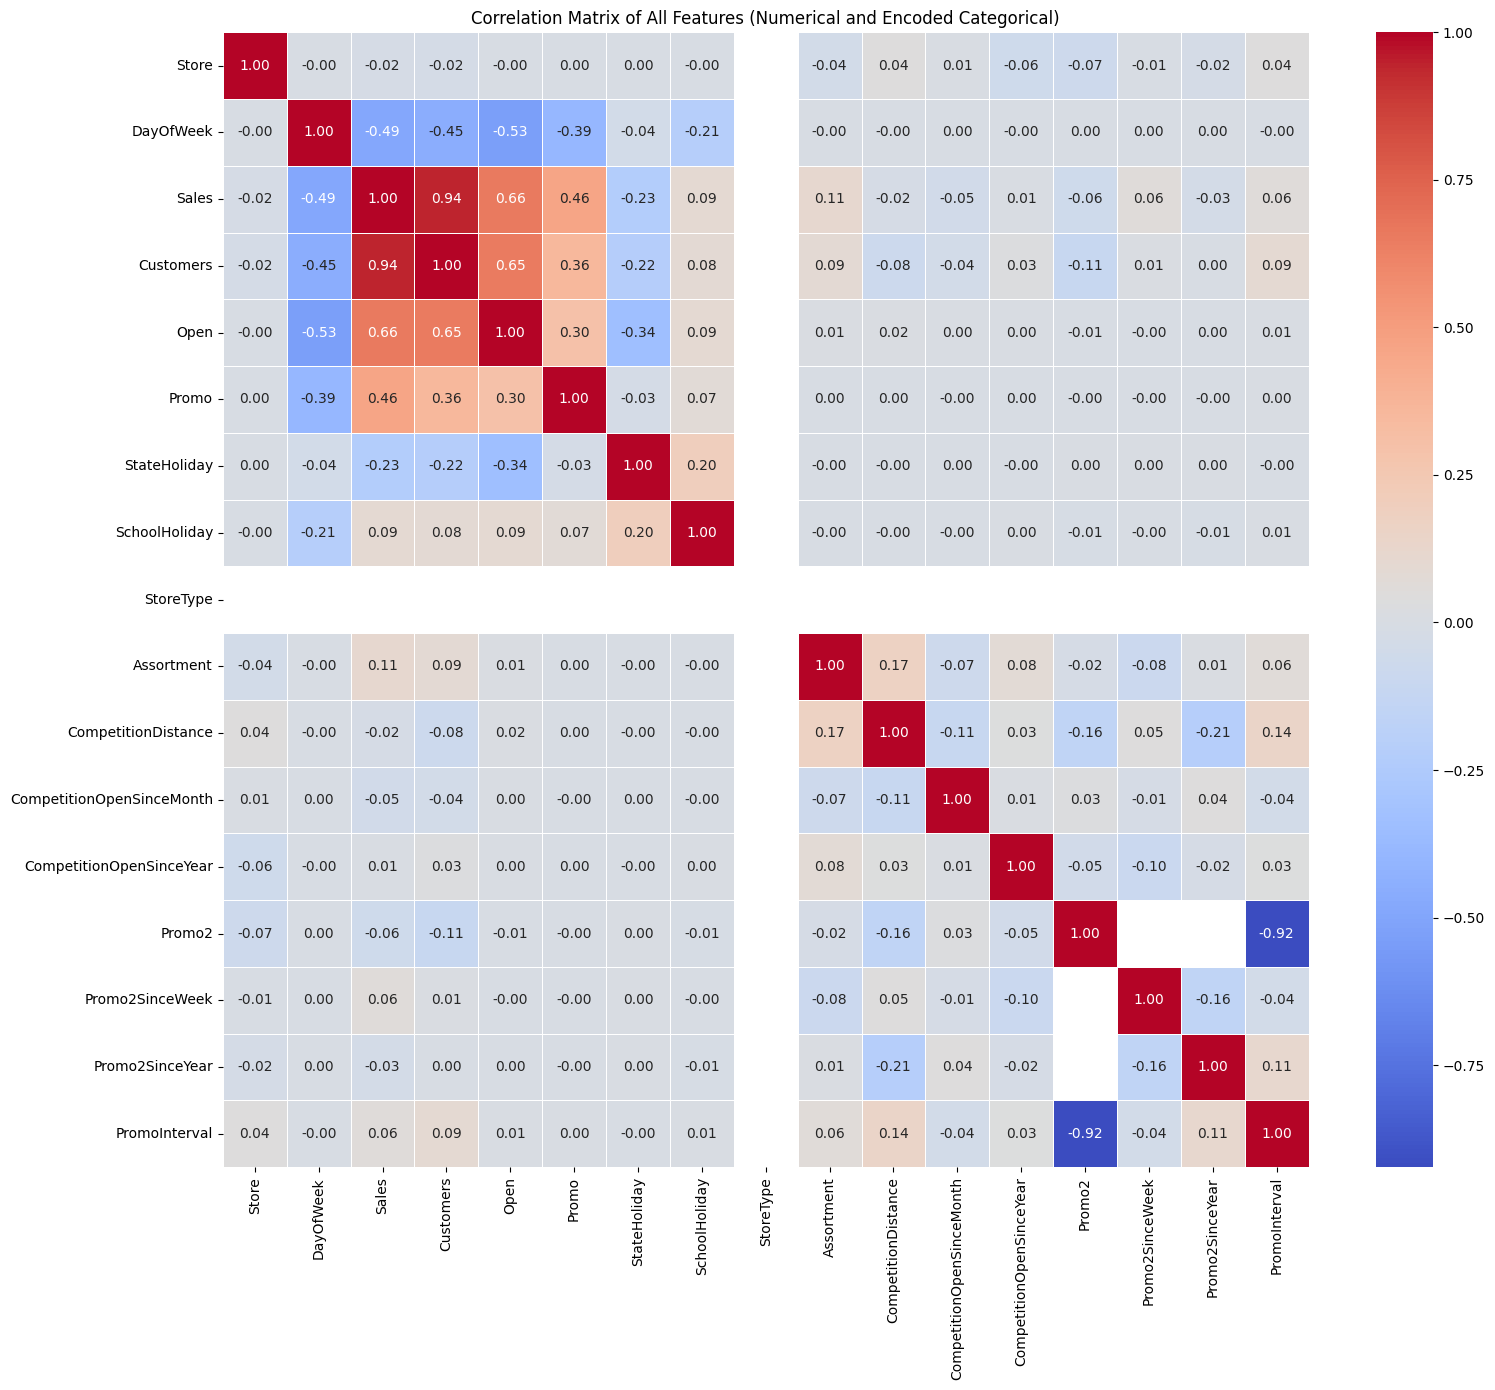

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Create a copy of the filtered_df to avoid modifying the original for this analysis
df_for_corr = filtered_df.copy()

# Exclude 'Date' column as it's not suitable for direct correlation matrix calculation
if 'Date' in df_for_corr.columns:
    df_for_corr = df_for_corr.drop(columns=['Date'])

# Identify categorical columns (object dtype or integer columns that represent categories)
categorical_cols = [
    'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'Promo2', 'PromoInterval'
]

# Convert 'Store' to object type if it's meant as a category and not a continuous identifier
# For correlation with other features, treating it as categorical might be more appropriate.
df_for_corr['Store'] = df_for_corr['Store'].astype(str)
categorical_cols.append('Store')

print("Converting categorical variables to numerical using Label Encoding...")
for col in categorical_cols:
    if col in df_for_corr.columns and (df_for_corr[col].dtype == 'object' or df_for_corr[col].nunique() < 50):
        # Fill NaN for PromoInterval before encoding, as LabelEncoder can't handle NaNs directly
        if df_for_corr[col].isnull().any():
            df_for_corr[col] = df_for_corr[col].fillna('No Info') # Or another suitable placeholder
        le = LabelEncoder()
        df_for_corr[col] = le.fit_transform(df_for_corr[col])
        print(f"  - Encoded '{col}'")


# Calculate the correlation matrix for all (now numerical) columns
# Drop any remaining non-numeric columns if they somehow snuck through
df_for_corr_numeric = df_for_corr.select_dtypes(include=['number'])
correlation_matrix_all = df_for_corr_numeric.corr()

# Display the correlation matrix
print("\nCorrelation Matrix for all Numerical and Encoded Categorical Columns:")
display(correlation_matrix_all)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features (Numerical and Encoded Categorical)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Identifying Features Highly Correlated with 'Sales'

In [18]:
# Extract correlations with 'Sales'
sales_correlations = correlation_matrix_all['Sales'].sort_values(ascending=False)

# Exclude 'Sales' itself from the list
sales_correlations = sales_correlations.drop('Sales')

print("\nFeatures ranked by correlation with 'Sales':")
display(sales_correlations)


Features ranked by correlation with 'Sales':


,Sales
Customers,0.944171
Open,0.658376
Promo,0.461717
Assortment,0.111206
SchoolHoliday,0.092738
PromoInterval,0.058917
Promo2SinceWeek,0.055541
CompetitionOpenSinceYear,0.008115
Store,-0.019023
CompetitionDistance,-0.020885


## Visualizing Top 6 Features Correlated with Sales


Visualizing the top 6 features correlated with 'Sales': ['Customers', 'Open', 'Promo', 'Assortment', 'SchoolHoliday', 'PromoInterval']

--- Plotting Sales vs Customers ---


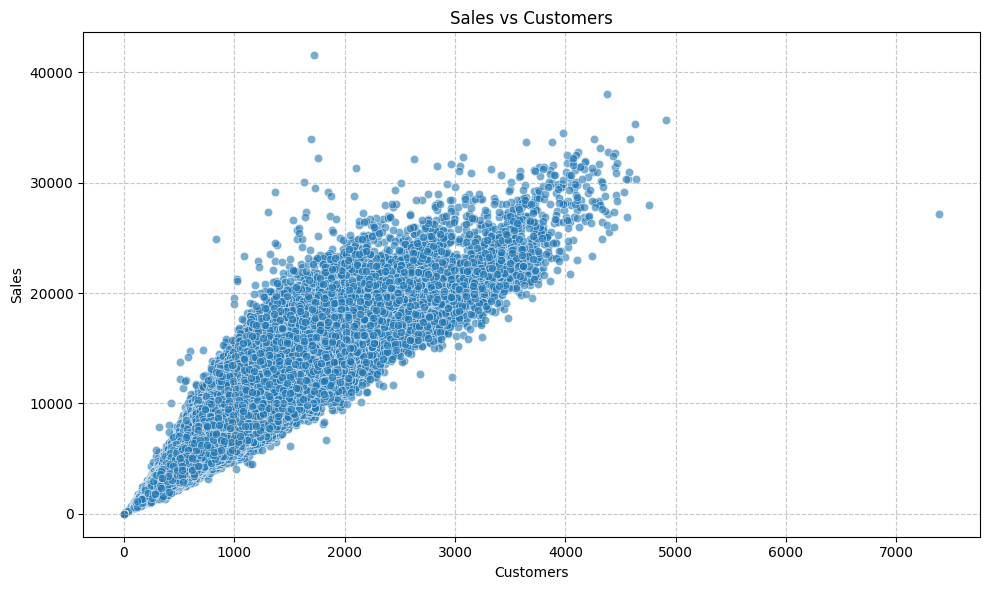


--- Plotting Sales vs Open ---


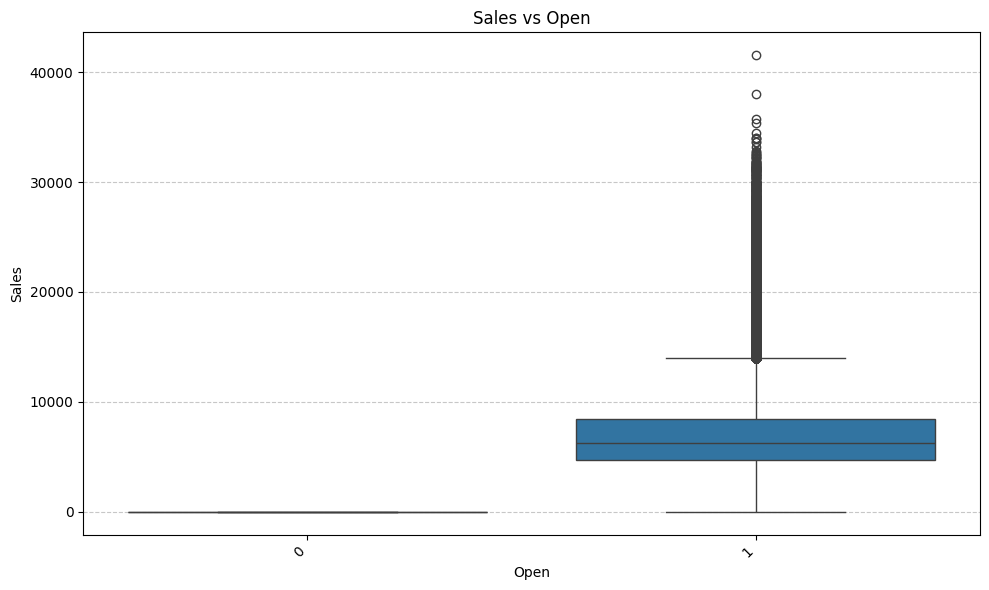


--- Plotting Sales vs Promo ---


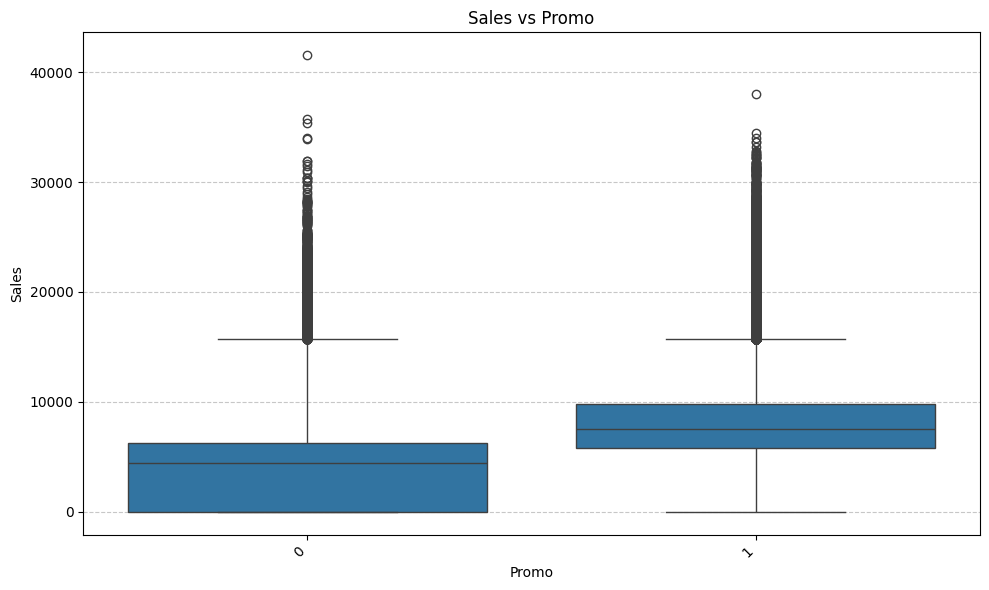


--- Plotting Sales vs Assortment ---


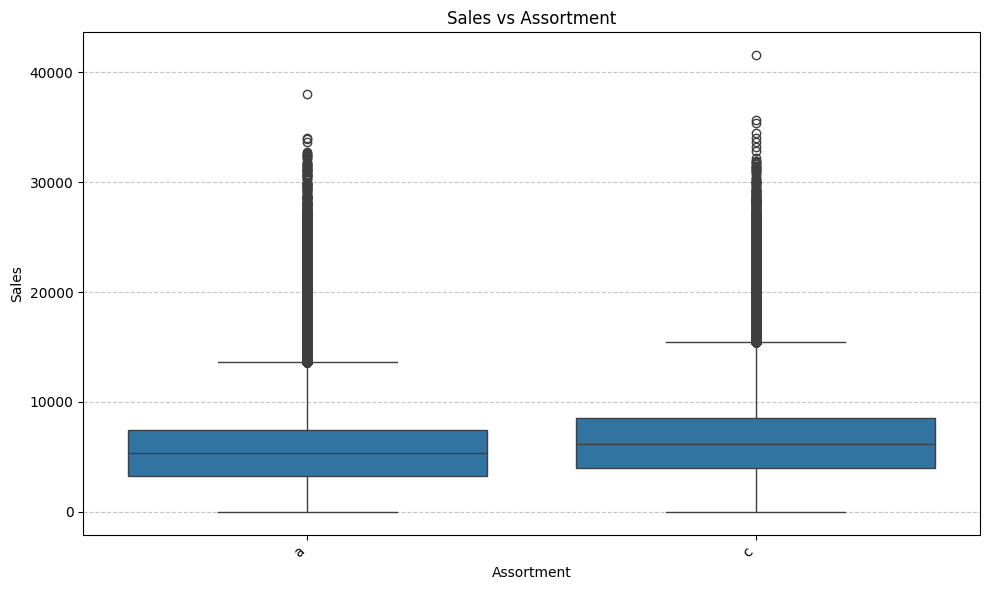


--- Plotting Sales vs SchoolHoliday ---


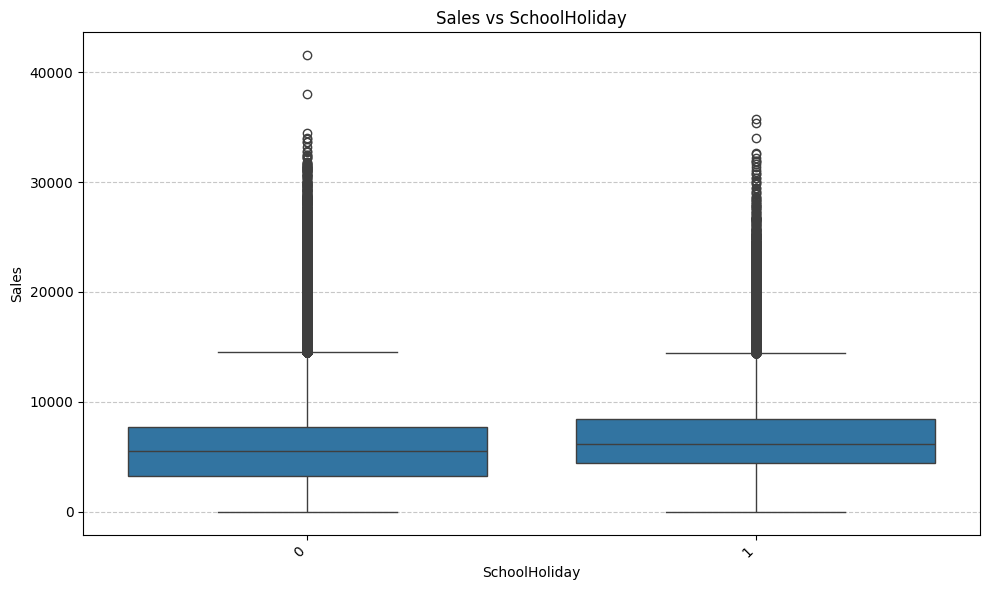


--- Plotting Sales vs PromoInterval ---


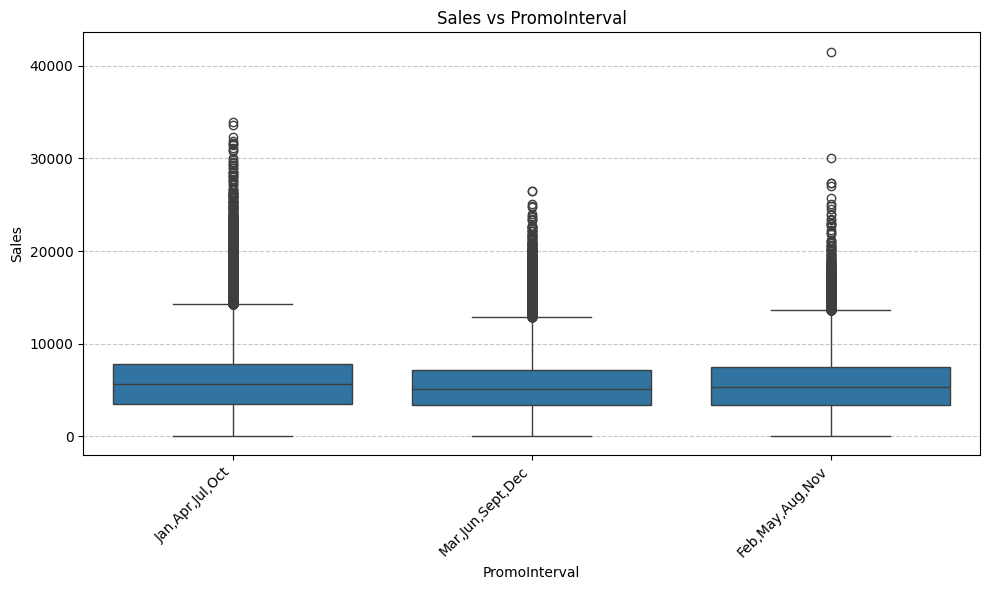

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get the top 6 features (excluding 'Sales' itself, which is already handled)
top_6_features = sales_correlations.head(6).index.tolist()

print(f"\nVisualizing the top 6 features correlated with 'Sales': {top_6_features}")

for col in top_6_features:
    print(f"\n--- Plotting Sales vs {col} ---")

    # Check the original dtype or unique values to decide on plot type
    if filtered_df[col].dtype in ['int64', 'float64'] and filtered_df[col].nunique() > 20:
        # Numerical feature: scatter plot
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=col, y='Sales', data=filtered_df, alpha=0.6)
        plt.title(f'Sales vs {col}')
        plt.xlabel(col)
        plt.ylabel('Sales')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        # Categorical or low-nunique numerical feature: box plot
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=col, y='Sales', data=filtered_df)
        plt.title(f'Sales vs {col}')
        plt.xlabel(col)
        plt.ylabel('Sales')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

## Impact of Promotions on Sales


Sales analysis based on Promo presence:


,Promo,mean,median,std,count
0,0,4300.418175,4408.0,3459.443557,341123
1,1,8068.080939,7544.0,3606.289324,210504


<Figure size 800x600 with 0 Axes>

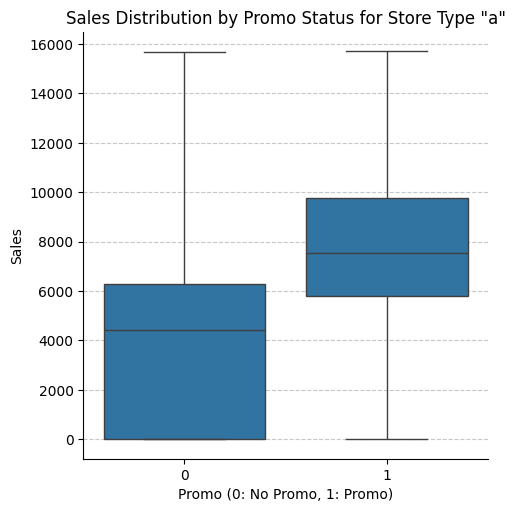

In [20]:
# Analyze sales as per promo presence
promo_sales_analysis = filtered_df.groupby('Promo')['Sales'].agg(['mean', 'median', 'std', 'count']).reset_index()
print("\nSales analysis based on Promo presence:")
display(promo_sales_analysis)

# Visualize the impact of Promo on sales
plt.figure(figsize=(8, 6))
#sns.boxplot(x='Promo', y='Sales', data=filtered_df)
sns.catplot(x='Promo', y='Sales', data=filtered_df,kind='box',showfliers=False)
#plt.title('Impact of Promotions on Sales')

plt.title('Sales Distribution by Promo Status for Store Type "a"')
plt.xlabel('Promo (0: No Promo, 1: Promo)')
plt.ylabel('Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Preprocessing for Linear Regression Model

In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create a copy for linear regression preprocessing
lr_df = filtered_df.copy()

# --- 1. Feature Engineering: Extract date features ---

lr_df['Year'] = lr_df['Date'].dt.year
lr_df['Month'] = lr_df['Date'].dt.month
lr_df['Day'] = lr_df['Date'].dt.day
lr_df['WeekOfYear'] = lr_df['Date'].dt.isocalendar().week.astype(int)
lr_df['DayOfYear'] = lr_df['Date'].dt.dayofyear

# Drop the original 'Date' column
lr_df = lr_df.drop(columns=['Date'])

# --- 2. Handle Missing Values ---

# Impute 'CompetitionDistance' with the median
imputer_median = SimpleImputer(strategy='median')
lr_df['CompetitionDistance'] = imputer_median.fit_transform(lr_df[['CompetitionDistance']])

# Fill other 'CompetitionOpenSince' and 'Promo2Since' NaNs with 0 (assuming NaN means not open/started yet)
# These are 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear'
for col in ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear']:
    lr_df[col] = lr_df[col].fillna(0)

# Fill 'PromoInterval' NaNs with 'NoPromo2'
lr_df['PromoInterval'] = lr_df['PromoInterval'].fillna('NoPromo2')

# --- 3. One-Hot Encode Categorical Features ---

# Identify categorical columns for one-hot encoding.
# 'StoreType' is constant 'a' for filtered_df, so it will be dropped by OHE if it only has one unique value, or it will create a single column
# 'Open', 'Promo', 'SchoolHoliday', 'Promo2' are already binary (0/1) and can be used directly.
# 'Store' will be dropped to avoid high dimensionality for simple linear regression, or could be label encoded if desired.
categorical_features = ['DayOfWeek', 'StateHoliday', 'Assortment', 'PromoInterval', 'StoreType']

# Drop 'Store' column to avoid high cardinality issues for a basic linear regression model
lr_df = lr_df.drop(columns=['Store'])

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply OneHotEncoder to categorical features
ohe_output = ohe.fit_transform(lr_df[categorical_features])
ohe_df = pd.DataFrame(ohe_output, columns=ohe.get_feature_names_out(categorical_features), index=lr_df.index)

# Drop original categorical features and concatenate one-hot encoded features
lr_df = lr_df.drop(columns=categorical_features)
lr_df = pd.concat([lr_df, ohe_df], axis=1)

# --- 4. Scaling Numerical Features (Optional but Recommended) ---

# Identify numerical features to scale
# Exclude target 'Sales' from scaling for now, but will need to be scaled for some models
numerical_features_to_scale = lr_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Sales' in numerical_features_to_scale:
    numerical_features_to_scale.remove('Sales') # Keep target unscaled for now

scaler = StandardScaler()
lr_df[numerical_features_to_scale] = scaler.fit_transform(lr_df[numerical_features_to_scale])

print("Preprocessed DataFrame for Linear Regression (lr_df) head:")
display(lr_df.head())
print(f"Shape of lr_df: {lr_df.shape}")

Preprocessed DataFrame for Linear Regression (lr_df) head:


,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,...,StateHoliday_a,StateHoliday_b,StateHoliday_c,Assortment_a,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_NoPromo2,StoreType_a
1,6064,-0.073521,0.454816,1.272991,2.145979,-0.541443,1.392616,0.641811,1.067255,0.128799,...,-0.141533,-0.081185,-0.063854,0.769745,-0.769745,-0.350431,1.602599,-0.290628,-1.067255,0.0
2,8314,0.349870,0.454816,1.272991,2.145979,1.057874,1.627643,0.640717,1.067255,0.195204,...,-0.141533,-0.081185,-0.063854,0.769745,-0.769745,-0.350431,1.602599,-0.290628,-1.067255,0.0
4,4822,-0.216091,0.454816,1.272991,2.145979,2.919025,-0.252574,0.650563,-0.936983,-0.734470,...,-0.141533,-0.081185,-0.063854,0.769745,-0.769745,-0.350431,-0.623987,-0.290628,0.936983,0.0
5,5651,-0.151286,0.454816,1.272991,2.145979,-0.572108,1.627643,0.648375,-0.936983,-0.734470,...,-0.141533,-0.081185,-0.063854,0.769745,-0.769745,-0.350431,-0.623987,-0.290628,0.936983,0.0
6,15344,1.630841,0.454816,1.272991,2.145979,2.221978,-0.252574,0.648375,-0.936983,-0.734470,...,-0.141533,-0.081185,-0.063854,-1.299132,1.299132,-0.350431,-0.623987,-0.290628,0.936983,0.0


Shape of lr_df: (551627, 34)


## Linear Regression Model Training and Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = lr_df.drop(columns=['Sales'])
y = lr_df['Sales']

# Split the data into training and testing sets
# Using a 80/20 split, with a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize and train the Linear Regression model
print("\nTraining Linear Regression Model...")
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the training set
y_train_pred = model.predict(X_train)

# Make predictions on the test set
y_test_pred = model.predict(X_test)

print("\n--- Model Evaluation on Training Data ---")
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print(f"Mean Absolute Error (MAE): {mae_train:.2f}")
print(f"Mean Squared Error (MSE): {mse_train:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.2f}")
print(f"R-squared (R2): {r2_train:.4f}")

print("\n--- Model Evaluation on Test Data ---")
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print(f"Mean Absolute Error (MAE): {mae_test:.2f}")
print(f"Mean Squared Error (MSE): {mse_test:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.2f}")
print(f"R-squared (R2): {r2_test:.4f}")

# Display coefficients and intercept (optional)
print("\nModel Coefficients:")
display(pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_}).sort_values(by='Coefficient', ascending=False))
print(f"Intercept: {model.intercept_:.2f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a figure with two subplots (one for train, one for test)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plotting Training Data Predictions ---
axes[0].scatter(y_train, y_train_pred, alpha=0.3, color='blue', label='Predictions')
# Plot the ideal prediction line (y=x)
max_val_train = max(y_train.max(), y_train_pred.max())
min_val_train = min(y_train.min(), y_train_pred.min())
axes[0].plot([min_val_train, max_val_train], [min_val_train, max_val_train], color='red', linestyle='--', label='Ideal Prediction')
axes[0].set_title('Linear Regression: Actual vs. Predicted Sales (Training Data)')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# --- Plotting Test Data Predictions ---
axes[1].scatter(y_test, y_test_pred, alpha=0.3, color='green', label='Predictions')
# Plot the ideal prediction line (y=x)
max_val_test = max(y_test.max(), y_test_pred.max())
min_val_test = min(y_test.min(), y_test_pred.min())
axes[1].plot([min_val_test, max_val_test], [min_val_test, max_val_test], color='red', linestyle='--', label='Ideal Prediction')
axes[1].set_title('Linear Regression: Actual vs. Predicted Sales (Test Data)')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

## Preprocessing for Time Series Model

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Create a copy for time series preprocessing
ts_df = filtered_df.copy()

# --- 1. Sort Data by Store and Date ---
ts_df = ts_df.sort_values(by=['Store', 'Date']).reset_index(drop=True)

# --- 2. Feature Engineering: Extract date features ---
ts_df['Year'] = ts_df['Date'].dt.year
ts_df['Month'] = ts_df['Date'].dt.month
ts_df['Day'] = ts_df['Date'].dt.day
ts_df['WeekOfYear'] = ts_df['Date'].dt.isocalendar().week.astype(int)
ts_df['DayOfYear'] = ts_df['Date'].dt.dayofyear
ts_df['DayOfWeek'] = ts_df['Date'].dt.dayofweek # 0=Monday, 6=Sunday

# Drop the original 'Date' column
ts_df = ts_df.drop(columns=['Date'])

# --- 3. Handle Missing Values ---

# Impute 'CompetitionDistance' with the median
imputer_median_ts = SimpleImputer(strategy='median')
ts_df['CompetitionDistance'] = imputer_median_ts.fit_transform(ts_df[['CompetitionDistance']])

# Fill other 'CompetitionOpenSince' and 'Promo2Since' NaNs with 0
for col in ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear']:
    ts_df[col] = ts_df[col].fillna(0)

# Fill 'PromoInterval' NaNs with 'NoPromo2'
ts_df['PromoInterval'] = ts_df['PromoInterval'].fillna('NoPromo2')

# --- 4. Time Series Specific Feature Engineering (Lags and Rolling Statistics) ---

# Create lag features for 'Sales' for each store
ts_df['Sales_Lag_1'] = ts_df.groupby('Store')['Sales'].shift(1)
ts_df['Sales_Lag_7'] = ts_df.groupby('Store')['Sales'].shift(7) # Weekly lag

# Create rolling mean features for 'Sales' for each store
ts_df['Sales_RollingMean_7'] = ts_df.groupby('Store')['Sales'].rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True)

# --- 5. Handle NaNs introduced by lag/rolling features ---
# For time series, these NaNs typically occur at the beginning of each store's series
# We can fill them with 0, or drop rows, or use forward/backward fill. Filling with 0 here.
for col in ['Sales_Lag_1', 'Sales_Lag_7', 'Sales_RollingMean_7']:
    ts_df[col] = ts_df[col].fillna(0)

# --- 6. One-Hot Encode Categorical Features ---
# 'StoreType' is constant, 'Open', 'Promo', 'SchoolHoliday', 'Promo2' are binary.
# 'DayOfWeek' is now numerical (0-6) from dt.dayofweek, but still categorical in nature.
categorical_features_ts = ['DayOfWeek', 'StateHoliday', 'Assortment', 'PromoInterval', 'StoreType']

# Drop 'Store' column to simplify for time series modeling (if modeling each store separately, 'Store' isn't a feature)
ts_df = ts_df.drop(columns=['Store'])

# Initialize OneHotEncoder
ohe_ts = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply OneHotEncoder to categorical features
ohe_output_ts = ohe_ts.fit_transform(ts_df[categorical_features_ts])
ohe_df_ts = pd.DataFrame(ohe_output_ts, columns=ohe_ts.get_feature_names_out(categorical_features_ts), index=ts_df.index)

# Drop original categorical features and concatenate one-hot encoded features
ts_df = ts_df.drop(columns=categorical_features_ts)
ts_df = pd.concat([ts_df, ohe_df_ts], axis=1)

# --- 7. Scaling Numerical Features (Optional but Recommended) ---

# Identify numerical features to scale
numerical_features_to_scale_ts = ts_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Sales' in numerical_features_to_scale_ts:
    numerical_features_to_scale_ts.remove('Sales') # Keep target unscaled for now

scaler_ts = StandardScaler()
ts_df[numerical_features_to_scale_ts] = scaler_ts.fit_transform(ts_df[numerical_features_to_scale_ts])

print("Preprocessed DataFrame for Time Series Model (ts_df) head:")
display(ts_df.head())
print(f"Shape of ts_df: {ts_df.shape}")

## Time Series Analysis: Trend, Seasonality, and Stationarity

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd

# Ensure 'Date' column is datetime and set as index for time series analysis
# We will use filtered_df here as ts_df has already dropped the 'Date' column.
# Make a fresh copy to avoid modifying filtered_df for other parts if needed.
time_series_df = filtered_df.copy()
time_series_df['Date'] = pd.to_datetime(time_series_df['Date'])
time_series_df = time_series_df.set_index('Date').sort_index()

# Aggregate daily sales across all stores (or pick a representative store if preferred)
# For simplicity, we'll aggregate total sales per day.
daily_sales = time_series_df.groupby('Date')['Sales'].sum()

print("--- Overall Daily Sales Time Series ---")
plt.figure(figsize=(15, 6))
daily_sales.plot(title='Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Time Series Decomposition (Trend, Seasonality, Residuals) ---
print("\n--- Time Series Decomposition ---")
# Use 'multiplicative' model if the magnitude of the seasonal variation changes with the level of the series.
# Use 'additive' if the magnitude of the seasonal variation is constant.
# Given sales data, often multiplicative is more appropriate if sales grow over time.
# We need at least 2 periods for decomposition. Here, frequency is daily, so freq=7 for weekly seasonality.

# Before decomposition, resample to ensure regular frequency. Use 'mean' or 'sum' as appropriate.
# Filling missing dates with 0 sales for simplicity for decomposition, assuming stores were closed.
# However, it's better to handle zero sales properly based on 'Open' column.
# Let's consider only days when stores were open and had sales > 0 for a cleaner decomposition.
# For a robust decomposition, we need a continuous series. Let's resample and fill NaNs.

daily_sales_filled = daily_sales.asfreq('D', fill_value=0) # Fill missing dates with 0

# Check for frequency. If the data is daily and we want weekly seasonality, set period=7.
# If there's monthly seasonality, set period=30 (approx).
# Let's assume weekly seasonality for now.

# Handle potential errors if series is too short or doesn't have enough periods for decomposition.
if len(daily_sales_filled) >= 2 * 7: # Need at least two cycles for seasonal decomposition
    try:
        decomposition = seasonal_decompose(daily_sales_filled, model='additive', period=7) # Assuming weekly seasonality

        fig = decomposition.plot()
        fig.set_size_inches(12, 8)
        fig.suptitle('Time Series Decomposition (Additive Model)', y=1.02) # Adjust suptitle position
        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
        plt.show()

        # --- Stationarity Test (Augmented Dickey-Fuller) ---
        print("\n--- Augmented Dickey-Fuller Test for Stationarity ---")
        result = adfuller(daily_sales.dropna()) # Test on the original daily sales, excluding NaNs
        print('ADF Statistic: %f' % result[0])
        print('p-value: %f' % result[1])
        print('Critical Values:')
        for key, value in result[4].items():
            print('\t%s: %.3f' % (key, value))

        if result[1] <= 0.05:
            print("The p-value is small (<= 0.05), so we reject the null hypothesis. The time series is likely stationary.")
        else:
            print("The p-value is large (> 0.05), so we fail to reject the null hypothesis. The time series is likely non-stationary.")

        # --- Autocorrelation and Partial Autocorrelation Plots ---
        print("\n--- Autocorrelation Function (ACF) Plot ---")
        plot_acf(daily_sales.dropna(), lags=30, title='Autocorrelation Function')
        plt.tight_layout()
        plt.show()

        print("\n--- Partial Autocorrelation Function (PACF) Plot ---")
        plot_pacf(daily_sales.dropna(), lags=30, title='Partial Autocorrelation Function')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not perform seasonal decomposition: {e}. Check data frequency and length.")
        print("Skipping decomposition, ADF, ACF/PACF plots due to decomposition error.")
else:
    print("Not enough data points for seasonal decomposition with period=7. Skipping decomposition, ADF, ACF/PACF plots.")

print("\n--- Time Series Analysis Complete ---")

In [ ]:
from sklearn.preprocessing import StandardScaler

# Aggregate daily 'Open' status. Summing 'Open' provides the count of open stores for 'StoreType a' each day.
daily_open_status = time_series_df.groupby('Date')['Open'].sum()

# Align the index of daily_open_status with daily_sales_filled
daily_open_status = daily_open_status.reindex(daily_sales_filled.index, fill_value=0) # Fill any missing dates with 0

# Scale the daily open status
scaler_exog = StandardScaler()
scaled_daily_open_status = scaler_exog.fit_transform(daily_open_status.values.reshape(-1, 1))
scaled_daily_open_status = pd.Series(scaled_daily_open_status.flatten(), index=daily_open_status.index, name='Scaled_Open_Status')

# Split into training and testing sets, aligned with daily_sales_filled splits
train_size = int(len(scaled_daily_open_status) * 0.9)
exog_train, exog_test = scaled_daily_open_status[0:train_size], scaled_daily_open_status[train_size:]

print("Prepared exogenous variable (Scaled Daily Open Status):")
print(f"Exog Train size: {len(exog_train)}")
print(f"Exog Test size: {len(exog_test)}")
display(scaled_daily_open_status.head())

Now, we will update the SARIMA model to use this `Scaled_Open_Status` as an exogenous variable, which should significantly improve its ability to predict sales, especially on days when stores are closed.

### Summary of Time Series Analysis and Model Selection

Based on the visual inspection and statistical tests above, we can infer the following about the 'Sales' time series:

*   **Trend:** (Describe if an upward, downward, or no clear trend is observed from the trend plot).
*   **Seasonality:** (Describe if a recurring pattern is observed, e.g., weekly, monthly, from the seasonal plot).
*   **Stationarity:** (Based on the ADF test p-value, state if the series is stationary or non-stationary. If non-stationary, differencing will be required).

**Model Selection:**

*   If the series exhibits clear trend and/or seasonality and is non-stationary, an **ARIMA** (AutoRegressive Integrated Moving Average) model or a **SARIMA** (Seasonal ARIMA) model would be suitable. SARIMA is preferred if seasonality is present.
*   The ACF and PACF plots help in determining the `p`, `d`, `q` orders for ARIMA/SARIMA models:
    *   `p` (AR order): Number of lags to be included in the model (from PACF).
    *   `d` (I order): Number of differences needed to make the series stationary (from ADF test and trend/seasonality observations).
    *   `q` (MA order): Number of lagged forecast errors in the prediction equation (from ACF).
*   For SARIMA, additional seasonal orders `P`, `D`, `Q`, and `S` (seasonal period) will be considered.

Now, we will proceed to building a time series model using `ts_df` which includes engineered time-series features like lags and rolling means, often making it suitable for tree-based models or more complex deep learning approaches in addition to statistical time series models.

## Time Series Model Building: Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (X_ts) and target (y_ts) for the time series model
# ts_df already has 'Store' dropped and other preprocessing applied.
X_ts = ts_df.drop(columns=['Sales'])
y_ts = ts_df['Sales']

# Time-based splitting for time series data
# It's crucial to avoid data leakage by training on past data and testing on future data.
# Let's use the last 20% of the data as the test set.

split_point = int(len(ts_df) * 0.8)
X_train_ts, X_test_ts = X_ts.iloc[:split_point], X_ts.iloc[split_point:]
y_train_ts, y_test_ts = y_ts.iloc[:split_point], y_ts.iloc[split_point:]

print(f"X_train_ts shape: {X_train_ts.shape}")
print(f"X_test_ts shape: {X_test_ts.shape}")
print(f"y_train_ts shape: {y_train_ts.shape}")
print(f"y_test_ts shape: {y_test_ts.shape}")

# Initialize and train a Random Forest Regressor
# Random Forest can capture non-linear relationships and interactions.
print("\nTraining Random Forest Regressor for Time Series...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 to use all available cores
rf_model.fit(X_train_ts, y_train_ts)
print("Random Forest Model training complete.")

# Make predictions on the training set
y_train_pred_ts = rf_model.predict(X_train_ts)

# Make predictions on the test set
y_test_pred_ts = rf_model.predict(X_test_ts)

print("\n--- Random Forest Model Evaluation on Training Data (Time Series) ---")
mae_train_ts = mean_absolute_error(y_train_ts, y_train_pred_ts)
mse_train_ts = mean_squared_error(y_train_ts, y_train_pred_ts)
rmse_train_ts = np.sqrt(mse_train_ts)
r2_train_ts = r2_score(y_train_ts, y_train_pred_ts)

print(f"Mean Absolute Error (MAE): {mae_train_ts:.2f}")
print(f"Mean Squared Error (MSE): {mse_train_ts:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train_ts:.2f}")
print(f"R-squared (R2): {r2_train_ts:.4f}")

print("\n--- Random Forest Model Evaluation on Test Data (Time Series) ---")
mae_test_ts = mean_absolute_error(y_test_ts, y_test_pred_ts)
mse_test_ts = mean_squared_error(y_test_ts, y_test_pred_ts)
rmse_test_ts = np.sqrt(mse_test_ts)
r2_test_ts = r2_score(y_test_ts, y_test_pred_ts)

print(f"Mean Absolute Error (MAE): {mae_test_ts:.2f}")
print(f"Mean Squared Error (MSE): {mse_test_ts:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test_ts:.2f}")
print(f"R-squared (R2): {r2_test_ts:.4f}")

## Time Series Model Forecast Visualization

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Visualize actual vs. predicted sales for the test set
plt.figure(figsize=(18, 7))
plt.plot(y_test_ts.index, y_test_ts.values, label='Actual Sales', color='blue', alpha=0.7)
plt.plot(y_test_ts.index, y_test_pred_ts, label='Predicted Sales', color='red', linestyle='--', alpha=0.7)

plt.title('Time Series Model: Actual vs. Predicted Sales (Test Data)')
plt.xlabel('Date Index') # Note: Since Date column was dropped and index reset, this is now a numerical index.
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualize residuals (prediction errors)
residuals = y_test_ts - y_test_pred_ts
plt.figure(figsize=(15, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Distribution of Residuals (Prediction Errors)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(y_test_ts.index, residuals, color='purple', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals Over Time')
plt.xlabel('Date Index')
plt.ylabel('Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'y_test_ts' is not defined

<Figure size 1800x700 with 0 Axes>

## SARIMA Model Building

In [ ]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Ensure `daily_sales_filled` is available from previous steps
# If not, regenerate it (assuming it's derived from `filtered_df`)
if 'daily_sales_filled' not in locals():
    time_series_df = filtered_df.copy()
    time_series_df['Date'] = pd.to_datetime(time_series_df['Date'])
    time_series_df = time_series_df.set_index('Date').sort_index()
    daily_sales = time_series_df.groupby('Date')['Sales'].sum()
    daily_sales_filled = daily_sales.asfreq('D', fill_value=0)

# --- Scale the data ---
# Initialize the scaler
scaler = StandardScaler()

# Scale the entire time series data
scaled_daily_sales = scaler.fit_transform(daily_sales_filled.values.reshape(-1, 1))
scaled_daily_sales = pd.Series(scaled_daily_sales.flatten(), index=daily_sales_filled.index, name='Scaled_Sales')

# Split scaled data into training and testing sets (chronological split)
train_size = int(len(scaled_daily_sales) * 0.9)
train_data_scaled, test_data_scaled = scaled_daily_sales[0:train_size], scaled_daily_sales[train_size:]

# Keep original test data for evaluation on unscaled values
train_data_original, test_data_original = daily_sales_filled[0:train_size], daily_sales_filled[train_size:]

print(f"Training data size (scaled): {len(train_data_scaled)}")
print(f"Test data size (scaled): {len(test_data_scaled)}")

# Define SARIMA orders based on previous ACF/PACF and ADF test results, and model performance:
# - d=1: Introduced non-seasonal differencing to address overall trend.
# - D=1: Introduced seasonal differencing to address weekly seasonality (period=7).
# - p, q, P, Q are initial guesses. Will re-evaluate ACF/PACF of differenced series if needed.
order = (2, 1, 2)  # (p, d, q) for non-seasonal components
seasonal_order = (2, 1, 2, 7) # (P, D, Q, S) for seasonal components

print(f"\nFitting SARIMA model with order={order} and seasonal_order={seasonal_order} on scaled data...")

# Fit the SARIMA model on scaled data, including the exogenous variable
sarima_model = SARIMAX(train_data_scaled, exog=exog_train, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=True, enforce_invertibility=True)
sarima_results = sarima_model.fit(disp=False)

print("SARIMA model fitting complete.")
print(sarima_results.summary())


In [ ]:
# Re-run the evaluation cell after updating SARIMA parameters
# Make predictions on the scaled test set
start_index = len(train_data_scaled)
end_index = len(scaled_daily_sales) - 1

sarima_predictions_scaled = sarima_results.predict(start=start_index, end=end_index, dynamic=False)

# Inverse transform the predictions and actual test data to the original scale
sarima_predictions = scaler.inverse_transform(sarima_predictions_scaled.values.reshape(-1, 1)).flatten()
# Ensure the predictions Series has the correct index for plotting
sarima_predictions = pd.Series(sarima_predictions, index=test_data_original.index, name='SARIMA_Predictions_Original_Scale')

# Evaluate the model on original scale
mae_sarima = mean_absolute_error(test_data_original, sarima_predictions)
mse_sarima = mean_squared_error(test_data_original, sarima_predictions)
rmse_sarima = np.sqrt(mse_sarima)

print("\n--- SARIMA Model Evaluation on Test Data (Original Scale) ---")
print(f"Mean Absolute Error (MAE): {mae_sarima:.2f}")
print(f"Mean Squared Error (MSE): {mse_sarima:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sarima:.2f}")

# Plot actual vs. predicted sales (on original scale)
plt.figure(figsize=(15, 6))
plt.plot(train_data_original.index, train_data_original, label='Training Data', color='blue')
plt.plot(test_data_original.index, test_data_original, label='Actual Sales (Test Data)', color='green')
plt.plot(sarima_predictions.index, sarima_predictions, label='SARIMA Predictions', color='red', linestyle='--')

plt.title('SARIMA Model: Actual vs. Predicted Sales (Original Scale)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Re-run the evaluation cell after updating SARIMA parameters
# Make predictions on the scaled test set
start_index = len(train_data_scaled)
end_index = len(scaled_daily_sales) - 1

sarima_predictions_scaled = sarima_results.predict(start=start_index, end=end_index, dynamic=False, exog=exog_test)

# Inverse transform the predictions and actual test data to the original scale
sarima_predictions = scaler.inverse_transform(sarima_predictions_scaled.values.reshape(-1, 1)).flatten()
# Ensure the predictions Series has the correct index for plotting
sarima_predictions = pd.Series(sarima_predictions, index=test_data_original.index, name='SARIMA_Predictions_Original_Scale')

# Evaluate the model on original scale
mae_sarima = mean_absolute_error(test_data_original, sarima_predictions)
mse_sarima = mean_squared_error(test_data_original, sarima_predictions)
rmse_sarima = np.sqrt(mse_sarima)

print("\n--- SARIMA Model Evaluation on Test Data (Original Scale) ---")
print(f"Mean Absolute Error (MAE): {mae_sarima:.2f}")
print(f"Mean Squared Error (MSE): {mse_sarima:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sarima:.2f}")

# Plot actual vs. predicted sales (on original scale)
plt.figure(figsize=(15, 6))
plt.plot(train_data_original.index, train_data_original, label='Training Data', color='blue')
plt.plot(test_data_original.index, test_data_original, label='Actual Sales (Test Data)', color='green')
plt.plot(sarima_predictions.index, sarima_predictions, label='SARIMA Predictions', color='red', linestyle='--')

plt.title('SARIMA Model: Actual vs. Predicted Sales (Original Scale)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Make predictions on the test set
start_index = len(train_data)
end_index = len(daily_sales_filled) - 1

sarima_predictions = sarima_results.predict(start=start_index, end=end_index, dynamic=False)

# Evaluate the model
mae_sarima = mean_absolute_error(test_data, sarima_predictions)
mse_sarima = mean_squared_error(test_data, sarima_predictions)
rmse_sarima = np.sqrt(mse_sarima)

print("\n--- SARIMA Model Evaluation on Test Data ---")
print(f"Mean Absolute Error (MAE): {mae_sarima:.2f}")
print(f"Mean Squared Error (MSE): {mse_sarima:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sarima:.2f}")

# Plot actual vs. predicted sales
plt.figure(figsize=(15, 6))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Sales (Test Data)', color='green')
plt.plot(sarima_predictions.index, sarima_predictions, label='SARIMA Predictions', color='red', linestyle='--')

plt.title('SARIMA Model: Actual vs. Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
